#**Appliance Energy Demand Forecasting**

####**Author:** Ameer Hamza
####**Student ID:** 24178176
####**GitHub:** https://github.com/mh25afc/appliance-energy-forecasting


```
pip install pandas numpy matplotlib seaborn statsmodels
```

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 4)




##**Part 1: Data Preparation and Exploratory Data Analysis**

## 1.1 Load raw data and inspect

In [ ]:
df_raw = pd.read_csv('/content/energydata_complete.csv', parse_dates=['date'])
df_raw = df_raw.set_index('date').sort_index()

print("Shape:", df_raw.shape)
print("Date range:", df_raw.index.min(), "to", df_raw.index.max())
df_raw.head()

Shape: (19735, 28)
Date range: 2016-01-11 17:00:00 to 2016-05-27 18:00:00


,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
date,,,,,,,,,,,,,,,,,,,,,
2016-01-11 17:00:00,60,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,45.566667,...,17.033333,45.53,6.600000,733.5,92.0,7.000000,63.000000,5.3,13.275433,13.275433
2016-01-11 17:10:00,60,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,45.992500,...,17.066667,45.56,6.483333,733.6,92.0,6.666667,59.166667,5.2,18.606195,18.606195
2016-01-11 17:20:00,50,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,45.890000,...,17.000000,45.50,6.366667,733.7,92.0,6.333333,55.333333,5.1,28.642668,28.642668
2016-01-11 17:30:00,50,40,19.89,46.066667,19.2,44.590000,19.79,45.000000,18.890000,45.723333,...,17.000000,45.40,6.250000,733.8,92.0,6.000000,51.500000,5.0,45.410389,45.410389
2016-01-11 17:40:00,60,40,19.89,46.333333,19.2,44.530000,19.79,45.000000,18.890000,45.530000,...,17.000000,45.40,6.133333,733.9,92.0,5.666667,47.666667,4.9,10.084097,10.084097


In [ ]:
# Check for missing values
missing = df_raw.isna().sum()
print("Missing values per column:")
print(missing[missing > 0] if missing.sum() > 0 else "None dataset is complete.")

# Check for gaps in the timestamp index (expected: every 10 minutes)
full_range = pd.date_range(start=df_raw.index.min(), end=df_raw.index.max(), freq='10min')
missing_timestamps = full_range.difference(df_raw.index)
print(f"\nMissing 10-min timestamps in the index: {len(missing_timestamps)}")

Missing values per column:
None dataset is complete.

Missing 10-min timestamps in the index: 0


No missing values and no gaps in the timestamp index the dataset is complete at
10-minute resolution, so no imputation is required before resampling.

## 1.2 Resample to hourly resolution

In [ ]:
numeric_cols = df_raw.select_dtypes(include='number').columns
df = df_raw[numeric_cols].resample('1h').mean()

print("Hourly shape:", df.shape)
df[['Appliances', 'lights', 'T_out', 'RH_out']].head()

Hourly shape: (3290, 28)


,Appliances,lights,T_out,RH_out
date,,,,
2016-01-11 17:00:00,55.000000,35.000000,6.308333,92.000000
2016-01-11 18:00:00,176.666667,51.666667,5.941667,91.583333
2016-01-11 19:00:00,173.333333,25.000000,6.000000,89.750000
2016-01-11 20:00:00,125.000000,35.000000,6.000000,87.583333
2016-01-11 21:00:00,103.333333,23.333333,5.833333,87.416667


## 1.3 Initial time series plot

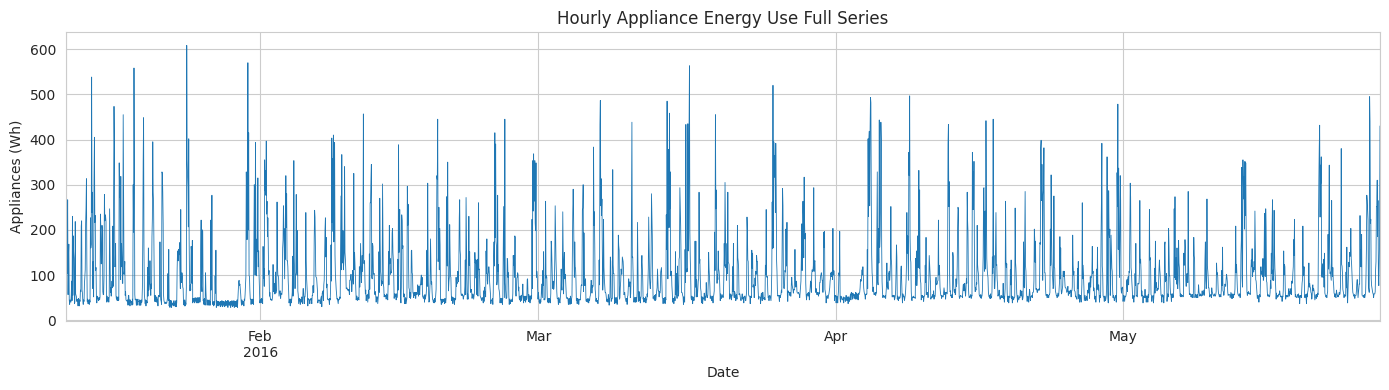

In [ ]:
fig, ax = plt.subplots(figsize=(14, 4))
df['Appliances'].plot(ax=ax, linewidth=0.6)
ax.set_title('Hourly Appliance Energy Use Full Series')
ax.set_ylabel('Appliances (Wh)')
ax.set_xlabel('Date')
plt.tight_layout()
plt.savefig('01_full_series.png', dpi=150)
plt.show()

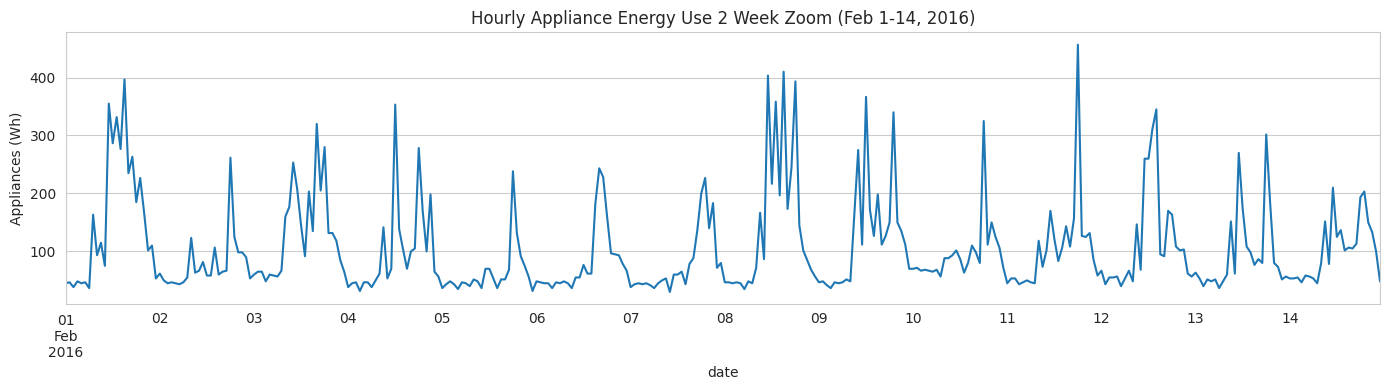

In [ ]:
# Zoom into a two-week window to see daily/weekly patterns clearly
fig, ax = plt.subplots(figsize=(14, 4))
df['Appliances'].loc['2016-02-01':'2016-02-14'].plot(ax=ax)
ax.set_title('Hourly Appliance Energy Use 2 Week Zoom (Feb 1-14, 2016)')
ax.set_ylabel('Appliances (Wh)')
plt.tight_layout()
plt.savefig('02_two_week_zoom.png', dpi=150)
plt.show()

## 1.4 Exploratory Data Analysis

Distribution, daily/weekly seasonal patterns, and correlations with sensor/weather variables.

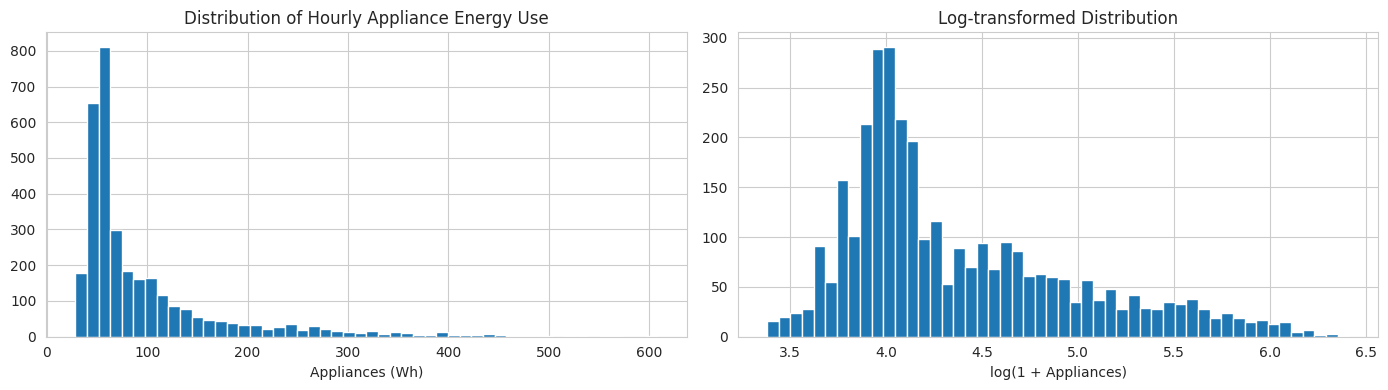

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
df['Appliances'].hist(bins=50, ax=axes[0])
axes[0].set_title('Distribution of Hourly Appliance Energy Use')
axes[0].set_xlabel('Appliances (Wh)')

np.log1p(df['Appliances']).hist(bins=50, ax=axes[1])
axes[1].set_title('Log-transformed Distribution')
axes[1].set_xlabel('log(1 + Appliances)')
plt.tight_layout()
plt.savefig('03_distribution.png', dpi=150)
plt.show()


In [ ]:
print(df['Appliances'].describe())

count    3290.000000
mean       97.779129
std        81.213695
min        28.333333
25%        50.000000
50%        63.333333
75%       110.000000
max       608.333333
Name: Appliances, dtype: float64


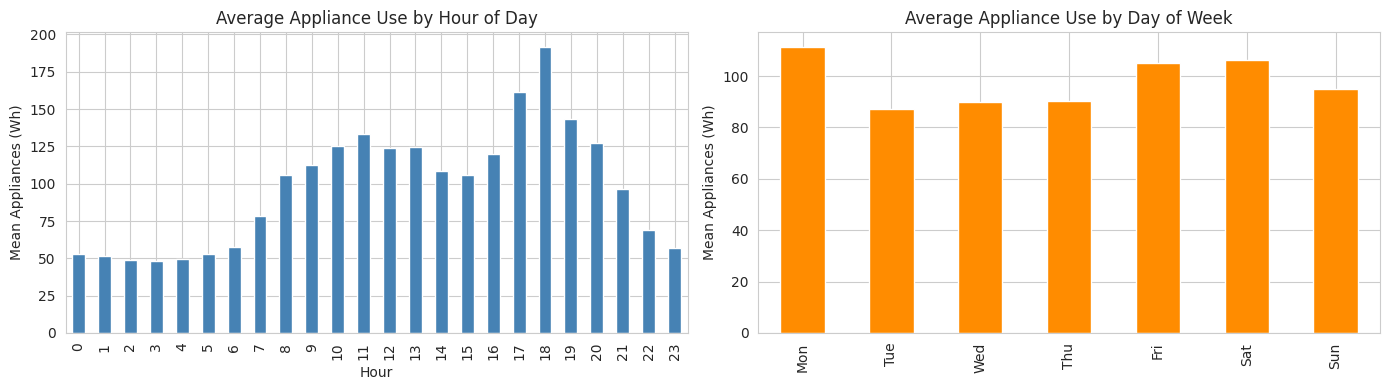

In [ ]:
# Average usage by hour-of-day and day-of-week
df_tmp = df.copy()
df_tmp['hour'] = df_tmp.index.hour
df_tmp['dayofweek'] = df_tmp.index.dayofweek

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

hourly_avg = df_tmp.groupby('hour')['Appliances'].mean()
hourly_avg.plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Average Appliance Use by Hour of Day')
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('Mean Appliances (Wh)')

dow_avg = df_tmp.groupby('dayofweek')['Appliances'].mean()
dow_avg.index = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
dow_avg.plot(kind='bar', ax=axes[1], color='darkorange')
axes[1].set_title('Average Appliance Use by Day of Week')
axes[1].set_ylabel('Mean Appliances (Wh)')

plt.tight_layout()
plt.savefig('04_hour_dow_avg.png', dpi=150)
plt.show()

**Observation:** there is a clear daily pattern (higher usage in morning/evening,
lower overnight) this is the daily seasonal component we'll need to capture.
Day-of-week differences are typically smaller but worth checking for a weekly effect
(e.g. weekend vs weekday).

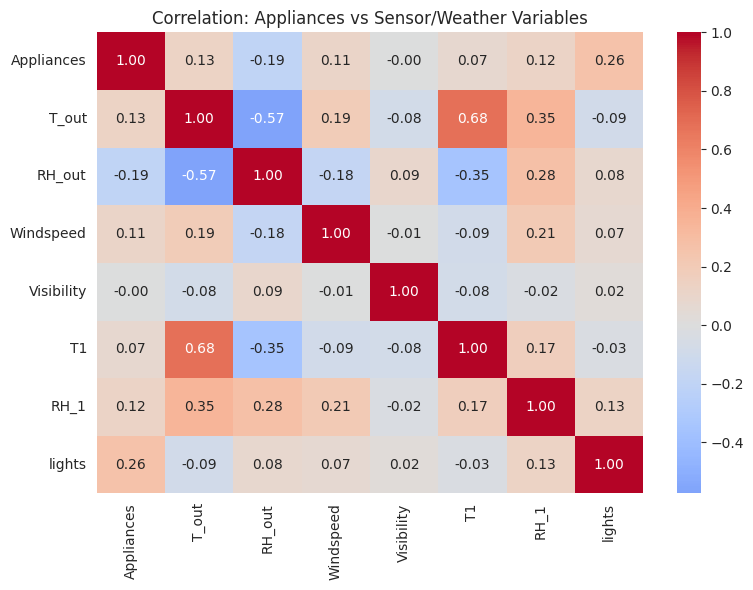

In [ ]:
# Correlation of Appliances with key sensor/weather variables
corr_cols = ['Appliances', 'T_out', 'RH_out', 'Windspeed', 'Visibility',
             'T1', 'RH_1', 'lights']
corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Correlation: Appliances vs Sensor/Weather Variables')
plt.tight_layout()
plt.savefig('05_correlation_heatmap.png', dpi=150)
plt.show()

## 1.5 Seasonal decomposition

Decompose the series into trend, seasonal, and residual components using STL
(Seasonal-Trend decomposition using LOESS), which handles non-sinusoidal seasonality
better than classical decomposition.

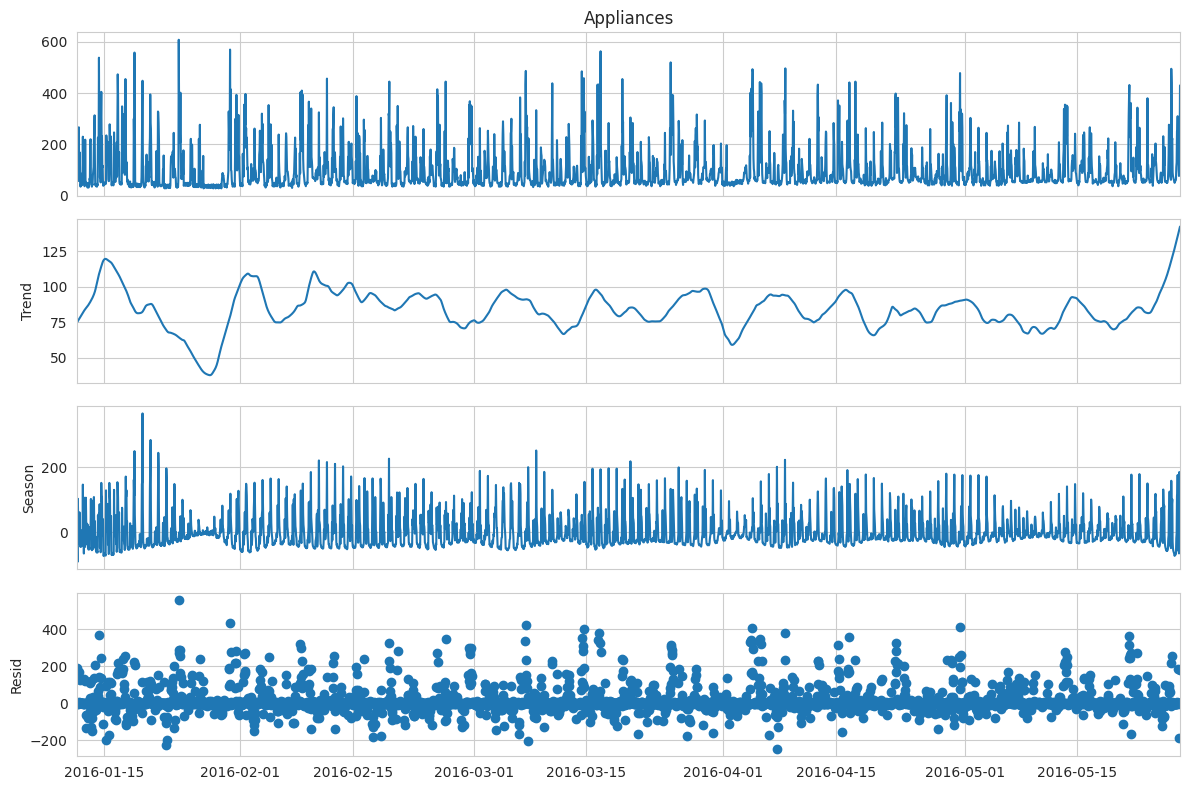

In [ ]:
# Daily seasonality: period = 24 (hours)
stl_daily = STL(df['Appliances'], period=24, robust=True).fit()

fig = stl_daily.plot()
fig.set_size_inches(12, 8)
plt.tight_layout()
plt.savefig('06_stl_decomposition_daily.png', dpi=150)
plt.show()

**Observation:** the seasonal component shows a repeating daily pattern with
consistent amplitude, confirming daily seasonality. The trend component captures
slower drift over the ~4.5 month period. We'll also check whether a weekly (period=168)
component is present.

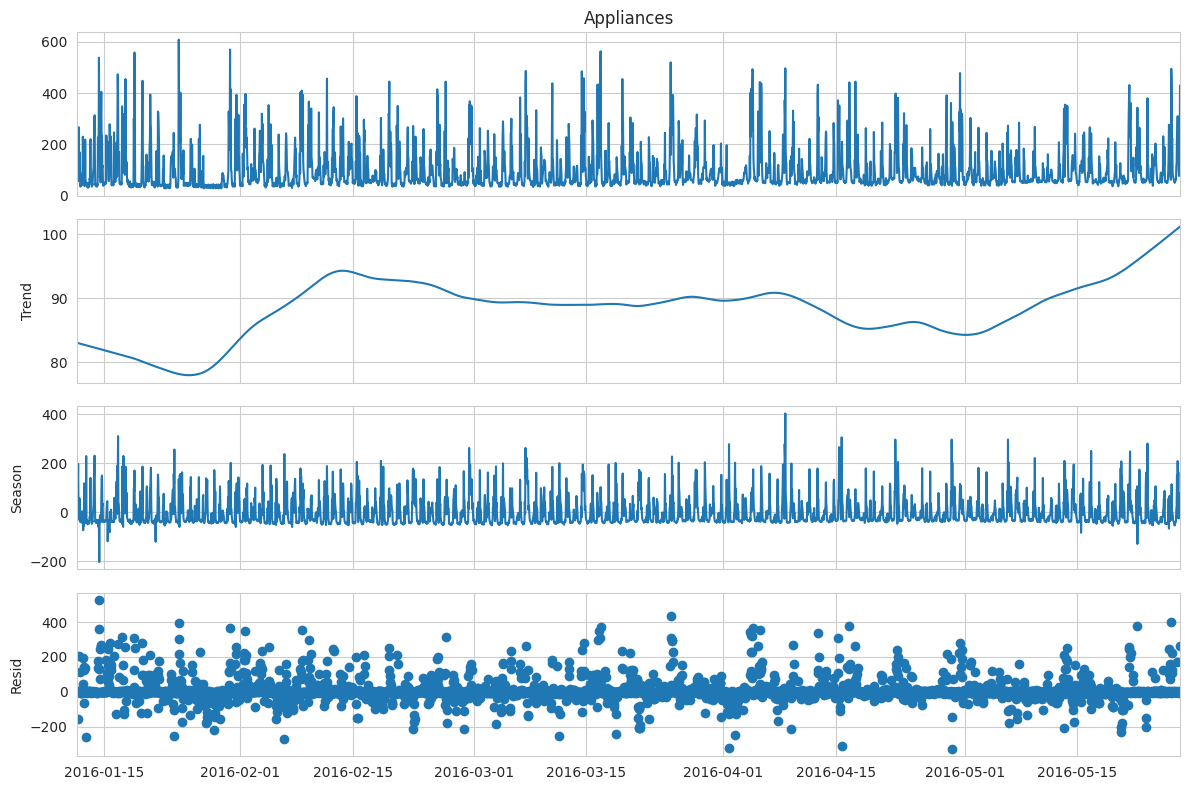

In [ ]:
# Weekly seasonality check: period = 24*7 = 168
stl_weekly = STL(df['Appliances'], period=168, robust=True).fit()

fig = stl_weekly.plot()
fig.set_size_inches(12, 8)
plt.tight_layout()
plt.savefig('07_stl_decomposition_weekly.png', dpi=150)
plt.show()

## 1.6 Autocorrelation

ACF/PACF plots help confirm the seasonal lag structure and inform later SARIMAX order selection.

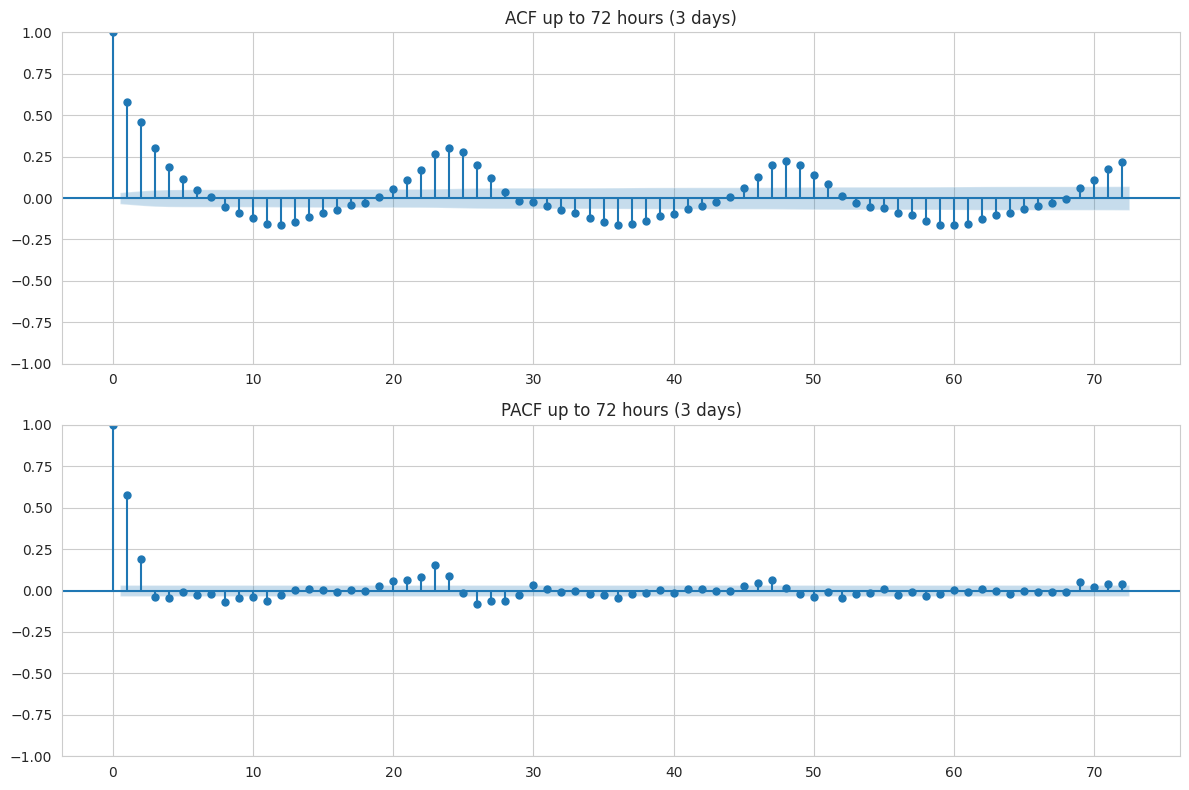

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8))
plot_acf(df['Appliances'], lags=72, ax=axes[0])
axes[0].set_title('ACF up to 72 hours (3 days)')
plot_pacf(df['Appliances'], lags=72, ax=axes[1], method='ywm')
axes[1].set_title('PACF up to 72 hours (3 days)')
plt.tight_layout()
plt.savefig('08_acf_pacf.png', dpi=150)
plt.show()

**Observation:** spikes at lag 24, 48, 72 in the ACF confirm the daily seasonal
period to use in SARIMAX.

## 1.7 Stationarity tests

Two complementary tests:
- **ADF (Augmented Dickey-Fuller)**: null hypothesis = series has a unit root (non-stationary).
  A low p-value (< 0.05) lets us reject non-stationarity.
- **KPSS**: null hypothesis = series IS stationary. A low p-value (< 0.05) means we reject
  stationarity.

Using both avoids relying on a single test's assumptions.

In [ ]:
def run_stationarity_tests(series, name='Series'):
    print(f"=== {name} ===")

    adf_result = adfuller(series.dropna(), autolag='AIC')
    print(f"ADF statistic: {adf_result[0]:.4f}")
    print(f"ADF p-value:   {adf_result[1]:.4f}")
    print(f"  -> {'Stationary' if adf_result[1] < 0.05 else 'Non-stationary'} (ADF, alpha=0.05)")

    kpss_result = kpss(series.dropna(), regression='c', nlags='auto')
    print(f"\nKPSS statistic: {kpss_result[0]:.4f}")
    print(f"KPSS p-value:   {kpss_result[1]:.4f}")
    print(f"  -> {'Non-stationary' if kpss_result[1] < 0.05 else 'Stationary'} (KPSS, alpha=0.05)")
    print()
    return adf_result, kpss_result

adf_res, kpss_res = run_stationarity_tests(df['Appliances'], 'Appliances (level)')

=== Appliances (level) ===
ADF statistic: -8.9489
ADF p-value:   0.0000
  -> Stationary (ADF, alpha=0.05)

KPSS statistic: 0.0384
KPSS p-value:   0.1000
  -> Stationary (KPSS, alpha=0.05)



/tmp/ipykernel_538/3613724675.py:9: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(series.dropna(), regression='c', nlags='auto')


In [ ]:
# First-order differencing
df['Appliances_diff1'] = df['Appliances'].diff()
adf_res_d1, kpss_res_d1 = run_stationarity_tests(df['Appliances_diff1'].dropna(), 'Appliances (1st difference)')

=== Appliances (1st difference) ===
ADF statistic: -16.9526
ADF p-value:   0.0000
  -> Stationary (ADF, alpha=0.05)

KPSS statistic: 0.0783
KPSS p-value:   0.1000
  -> Stationary (KPSS, alpha=0.05)



/tmp/ipykernel_538/3613724675.py:9: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(series.dropna(), regression='c', nlags='auto')


In [ ]:
# Seasonal (24h) differencing, relevant given the daily pattern observed above
df['Appliances_seasdiff24'] = df['Appliances'].diff(24)
adf_res_s24, kpss_res_s24 = run_stationarity_tests(df['Appliances_seasdiff24'].dropna(), 'Appliances (24h seasonal difference)')

=== Appliances (24h seasonal difference) ===
ADF statistic: -13.5934
ADF p-value:   0.0000
  -> Stationary (ADF, alpha=0.05)

KPSS statistic: 0.0087
KPSS p-value:   0.1000
  -> Stationary (KPSS, alpha=0.05)



/tmp/ipykernel_538/3613724675.py:9: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(series.dropna(), regression='c', nlags='auto')


**Summary of Part 1 findings (to carry into the report):**
- Dataset is complete: no missing values, no timestamp gaps at 10-min resolution.
- Resampled to hourly (mean aggregation) → 3,290 hourly observations over ~4.5 months
  (2016-01-11 to 2016-05-27).
- Clear **daily seasonal component** (period=24h) confirmed via STL decomposition, hour-of-day
  averages, and ACF spikes at multiples of 24. Weekly seasonality is comparatively weak.
- **Stationarity:** both ADF (p ≈ 0.0000, rejects unit root) and KPSS (p = 0.10, fails to
  reject stationarity) agree the series is already stationary in levels despite the
  strong daily seasonal swing, the mean and variance are stable over the ~4.5 month window,
  so there's no long-run trend or unit root. This is a level-stationary but seasonal series:
  SARIMA in Part 4 will still need a seasonal order (P,D,Q)_24 to capture the daily cycle
  itself, even though outright differencing for trend-stationarity isn't strictly required.
  We'll confirm this choice empirically via the AIC grid search.



##**Part 2: Define the Forecasting Problem**

## 2.1 Target variable

**Target: `Appliances`**: hourly-averaged appliance energy use (Wh), as prepared in Part 1.

## 2.2 Forecast horizon

**24 hours**: (fixed by the assignment spec), at hourly resolution  i.e. each forecast
produces 24 sequential hourly predictions from a given origin point.

## 2.3 Train / test split

- **Test period:** the **last 14 days** (336 hours) of the dataset, per the assignment spec
  for the ML model in Part 6 we apply the same test window consistently across *all*
  models (benchmarks, SARIMAX, ML, foundation model) so results are directly comparable.
- **Train period:** everything before the test window.
- Since the horizon is 24h but the test period is 14 days, we evaluate using **rolling-origin,
  non-overlapping 24-hour windows** across the 14-day test period (14 folds of 24h each).
  This gives a more robust estimate of forecast accuracy than a single 24h window, and
  matches the "evaluation design" the report needs to describe.



In [ ]:
# Train / test split
TEST_DAYS = 14
HORIZON = 24

test_hours = TEST_DAYS * 24
split_point = df.index[-test_hours]

train = df.loc[:split_point].iloc[:-1]
test = df.loc[split_point:]

print(f"Train: {train.index.min()} to {train.index.max()}  ({len(train)} hours)")
print(f"Test:  {test.index.min()} to {test.index.max()}  ({len(test)} hours)")
print(f"Test period covers {len(test) / HORIZON:.0f} non-overlapping {HORIZON}h folds")

Train: 2016-01-11 17:00:00 to 2016-05-13 18:00:00  (2954 hours)
Test:  2016-05-13 19:00:00 to 2016-05-27 18:00:00  (336 hours)
Test period covers 14 non-overlapping 24h folds


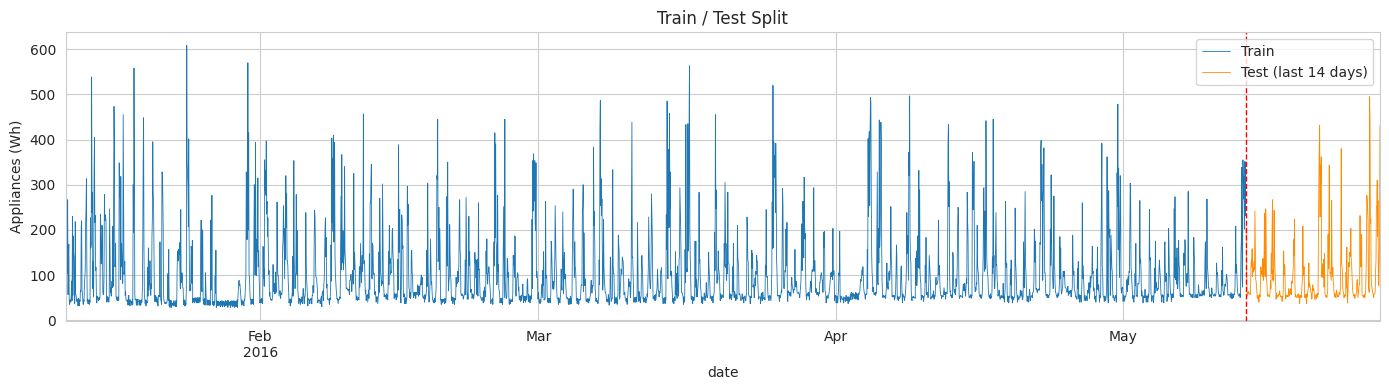

In [ ]:
# Visualize the split
fig, ax = plt.subplots(figsize=(14, 4))
train['Appliances'].plot(ax=ax, label='Train', linewidth=0.6)
test['Appliances'].plot(ax=ax, label='Test (last 14 days)', linewidth=0.6, color='darkorange')
ax.axvline(test.index.min(), color='red', linestyle='--', linewidth=1)
ax.set_title('Train / Test Split')
ax.set_ylabel('Appliances (Wh)')
ax.legend()
plt.tight_layout()
plt.savefig('09_train_test_split.png', dpi=150)
plt.show()

## 2.4 Evaluation metrics

- **RMSE** (Root Mean Squared Error): penalizes large errors, same units as target (Wh).
- **MAE** (Mean Absolute Error): average magnitude of error, robust to outliers, same units.
- **MAPE** (Mean Absolute Percentage Error): scale-free, easy to interpret; safe to use here
  since `Appliances` has no zero/near-zero values (min ≈ 28 Wh).

We compute metrics per fold and report the mean ± std across the 14 folds for each model,
rather than a single-window number, which is easy to cherry-pick.

In [ ]:
# Reusable evaluation metrics
def rmse(y_true, y_pred):
    return np.sqrt(np.mean((np.asarray(y_true) - np.asarray(y_pred)) ** 2))

def mae(y_true, y_pred):
    return np.mean(np.abs(np.asarray(y_true) - np.asarray(y_pred)))

def mape(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

def evaluate_forecast(y_true, y_pred):
    return {'RMSE': rmse(y_true, y_pred), 'MAE': mae(y_true, y_pred), 'MAPE': mape(y_true, y_pred)}

In [ ]:
# Reusable rolling-origin fold generator
def get_rolling_folds(df, test_start, horizon=HORIZON, n_folds=TEST_DAYS):
    """
    Returns a list of (train_end_time, forecast_index) tuples.
    train_end_time: last timestamp available to the model for this fold (exclusive of forecast window)
    forecast_index: the 24 timestamps to be forecast in this fold
    """
    folds = []
    start = test_start
    for i in range(n_folds):
        window_start = start + pd.Timedelta(hours=i * horizon)
        window_end = window_start + pd.Timedelta(hours=horizon - 1)
        if window_end > df.index.max():
            break
        forecast_index = df.loc[window_start:window_end].index
        train_end_time = window_start - pd.Timedelta(hours=1)
        folds.append((train_end_time, forecast_index))
    return folds

folds = get_rolling_folds(df, test_start=test.index.min())
print(f"Number of folds: {len(folds)}")
print(f"Fold 1 -> train ends: {folds[0][0]}, forecast: {folds[0][1].min()} to {folds[0][1].max()}")
print(f"Fold 14 -> train ends: {folds[-1][0]}, forecast: {folds[-1][1].min()} to {folds[-1][1].max()}")

Number of folds: 14
Fold 1 -> train ends: 2016-05-13 18:00:00, forecast: 2016-05-13 19:00:00 to 2016-05-14 18:00:00
Fold 14 -> train ends: 2016-05-26 18:00:00, forecast: 2016-05-26 19:00:00 to 2016-05-27 18:00:00


**Summary of Part 2 :**
- Target: `Appliances` (hourly Wh).
- Horizon: 24 hours ahead.
- Split: last 14 days (336 hours) held out as test; everything before is training data.
- Evaluation: 14 non-overlapping 24-hour rolling-origin folds across the test period,
  metrics (RMSE, MAE, MAPE) reported as mean ± std across folds not a single lucky window.
- `folds` and `evaluate_forecast()` defined here are reused unchanged by every model
  (benchmarks, SARIMAX, ML, foundation model) later in this notebook, so comparisons in
  Part 8 are apples-to-apples.


##**Part 3: Benchmark Models**

Five classical benchmarks, each producing a 24-hour-ahead forecast from a given origin.
These give us a baseline: any more complex model (SARIMAX, ML, foundation model) needs to
beat the strongest of these to be worth its added complexity.

- **Mean**: forecast = mean of all training history so far.
- **Naive**: forecast = last observed value, repeated for all 24 hours.
- **Daily seasonal naive**: forecast = value from exactly 24h before each forecast hour.
- **Weekly seasonal naive**: forecast = value from exactly 168h (7 days) before each forecast hour.
- **Drift**: naive + a linear trend extrapolated from the first to the last training observation.

In [ ]:
def forecast_mean(history, horizon=HORIZON):
    return np.full(horizon, history.mean())

def forecast_naive(history, horizon=HORIZON):
    return np.full(horizon, history.iloc[-1])

def forecast_seasonal_naive(history, season, horizon=HORIZON):
    """Repeats the last full seasonal cycle. season=24 -> daily, season=168 -> weekly."""
    last_season = history.iloc[-season:].values
    reps = int(np.ceil(horizon / season))
    return np.tile(last_season, reps)[:horizon]

def forecast_drift(history, horizon=HORIZON):
    y_first, y_last = history.iloc[0], history.iloc[-1]
    n = len(history)
    slope = (y_last - y_first) / (n - 1)
    return y_last + slope * np.arange(1, horizon + 1)

In [ ]:
# Run all benchmarks across the 14 rolling-origin folds
benchmark_models = {
    'Mean': lambda history: forecast_mean(history),
    'Naive': lambda history: forecast_naive(history),
    'Daily Seasonal Naive': lambda history: forecast_seasonal_naive(history, season=24),
    'Weekly Seasonal Naive': lambda history: forecast_seasonal_naive(history, season=168),
    'Drift': lambda history: forecast_drift(history),
}

benchmark_fold_results = {name: [] for name in benchmark_models}
benchmark_predictions = {name: [] for name in benchmark_models}  # keep for plotting later

for train_end_time, forecast_idx in folds:
    history = df.loc[:train_end_time, 'Appliances']
    y_true = df.loc[forecast_idx, 'Appliances'].values

    for name, model_fn in benchmark_models.items():
        y_pred = model_fn(history)
        metrics = evaluate_forecast(y_true, y_pred)
        benchmark_fold_results[name].append(metrics)
        benchmark_predictions[name].append((forecast_idx, y_pred))

print("Benchmarks run across all 14 folds.")

Benchmarks run across all 14 folds.


In [ ]:
# Aggregate metrics: mean +/- std across folds
summary_rows = []
for name, fold_metrics in benchmark_fold_results.items():
    fold_df = pd.DataFrame(fold_metrics)
    summary_rows.append({
        'Model': name,
        'RMSE_mean': fold_df['RMSE'].mean(), 'RMSE_std': fold_df['RMSE'].std(),
        'MAE_mean': fold_df['MAE'].mean(), 'MAE_std': fold_df['MAE'].std(),
        'MAPE_mean': fold_df['MAPE'].mean(), 'MAPE_std': fold_df['MAPE'].std(),
    })

benchmark_summary = pd.DataFrame(summary_rows).sort_values('RMSE_mean').reset_index(drop=True)
benchmark_summary

,Model,RMSE_mean,RMSE_std,MAE_mean,MAE_std,MAPE_mean,MAPE_std
0,Mean,66.913813,35.012168,50.258092,21.622900,53.695620,9.799094
1,Weekly Seasonal Naive,69.229499,44.450103,43.457341,29.688069,37.354106,35.245228
2,Daily Seasonal Naive,76.303126,40.180513,48.308532,24.810664,43.326910,21.820463
3,Naive,97.765829,53.196462,85.550595,51.758155,112.910665,68.690568
4,Drift,97.982185,53.415096,85.802089,52.035935,113.309050,69.007456


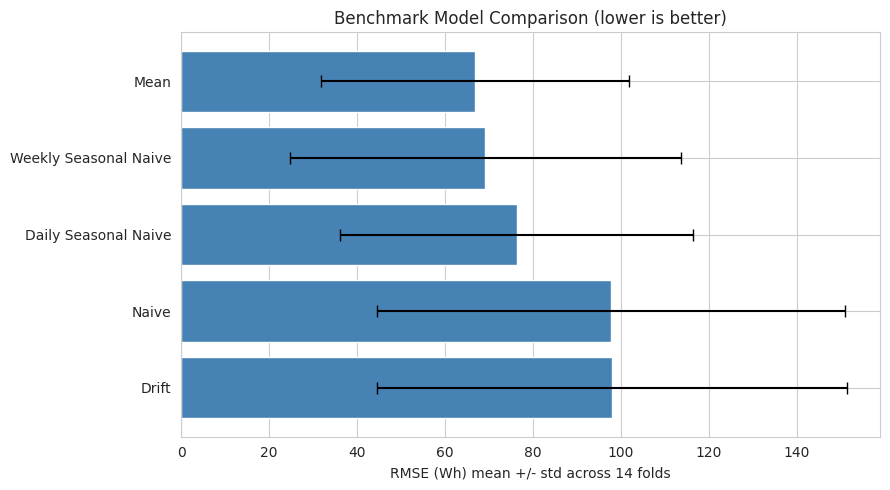

In [ ]:

benchmark_summary.to_csv('benchmark_summary.csv', index=False)

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(benchmark_summary['Model'], benchmark_summary['RMSE_mean'],
        xerr=benchmark_summary['RMSE_std'], color='steelblue', capsize=4)
ax.set_xlabel('RMSE (Wh) mean +/- std across 14 folds')
ax.set_title('Benchmark Model Comparison (lower is better)')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('10_benchmark_comparison.png', dpi=150)
plt.show()

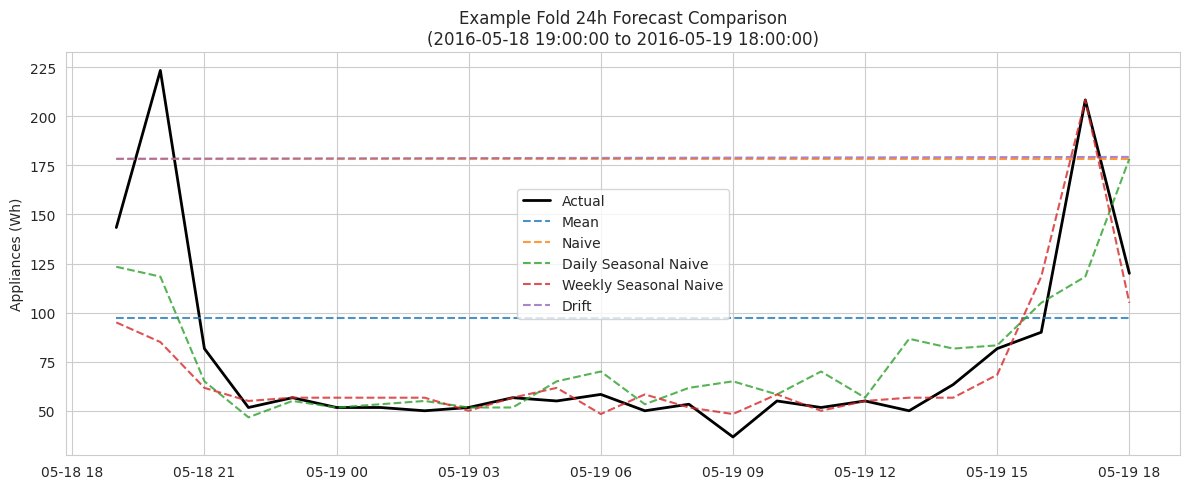

In [ ]:
# Visualize one example fold: actual vs. all benchmark forecasts
example_fold_idx = 5
forecast_idx, _ = benchmark_predictions['Naive'][example_fold_idx]
y_true = df.loc[forecast_idx, 'Appliances']

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(forecast_idx, y_true.values, label='Actual', color='black', linewidth=2)

for name in benchmark_models:
    _, y_pred = benchmark_predictions[name][example_fold_idx]
    ax.plot(forecast_idx, y_pred, label=name, linestyle='--', alpha=0.8)

ax.set_title(f'Example Fold 24h Forecast Comparison\n({forecast_idx.min()} to {forecast_idx.max()})')
ax.set_ylabel('Appliances (Wh)')
ax.legend()
plt.tight_layout()
plt.savefig('11_benchmark_example_fold.png', dpi=150)
plt.show()

**Summary of Part 3**
- All 5 benchmarks evaluated across the same 14 rolling-origin folds defined in Part 2.
- Results (mean across folds): **Mean** has the lowest RMSE (~ 66.9 Wh), but **Weekly
  Seasonal Naive** has the lowest MAE (~ 43.5 Wh) and MAPE (~ 37.4%). Daily Seasonal Naive
  is competitive but behind Weekly on all three metrics here. Naive and Drift are clearly
  worst (RMSE ~ 98).



##**Part 4: SARIMAX**

Part 1 confirmed the series is already stationary in levels (ADF + KPSS agree), but has a
strong **daily (24h) seasonal component**. This motivates a **SARIMA** model with a seasonal
order at period 24, rather than heavy differencing.

**Order selection:** the assignment requires an AIC grid search over p=[0,6], d=[0,2],
q=[0,6] (147 combinations). Fitting all 147 with a seasonal term on the full ~2,954-hour
training set would be very slow, so we run the grid search on a **recent 21-day subset**
(fast, still representative of current dynamics) with the seasonal order fixed at
`(1,0,1,24)` justified by the daily seasonality confirmed in Part 1. Once the best
(p,d,q) is found, we refit on the **full training set** for the actual forecasts.

In [ ]:
import warnings
import itertools
from statsmodels.tsa.statespace.sarimax import SARIMAX

warnings.filterwarnings('ignore')

In [ ]:
# AIC grid search on a recent subset for speed
SEASONAL_ORDER = (1, 0, 1, 24)
search_window_days = 21
search_data = train['Appliances'].iloc[-search_window_days * 24:]

p_range = range(0, 7)
d_range = range(0, 3)
q_range = range(0, 7)

results = []
for p, d, q in itertools.product(p_range, d_range, q_range):
    try:
        model = SARIMAX(search_data, order=(p, d, q), seasonal_order=SEASONAL_ORDER,
                         enforce_stationarity=False, enforce_invertibility=False)
        fit = model.fit(disp=False, maxiter=30, method='lbfgs')
        results.append({'p': p, 'd': d, 'q': q, 'AIC': fit.aic})
    except Exception:
        continue

grid_results = pd.DataFrame(results).sort_values('AIC').reset_index(drop=True)
print(f"Successfully fit {len(grid_results)} / {len(list(itertools.product(p_range, d_range, q_range)))} combinations")
grid_results.head(10)

Successfully fit 147 / 147 combinations


,p,d,q,AIC
0,2,1,6,5101.428212
1,0,1,6,5103.155967
2,1,1,6,5104.648323
3,3,1,6,5105.803950
4,6,1,6,5106.204890
5,4,1,6,5107.716945
6,5,1,6,5109.163196
7,1,1,5,5112.106603
8,0,1,5,5112.515668
9,6,1,1,5113.335463


In [ ]:
# Save full grid search results for the report/appendix
grid_results.to_csv('sarimax_grid_search.csv', index=False)

best_p, best_d, best_q = grid_results.iloc[0][['p', 'd', 'q']].astype(int)
BEST_ORDER = (best_p, best_d, best_q)
print(f"Best order by AIC: {BEST_ORDER}, seasonal_order: {SEASONAL_ORDER}")
print(f"Best AIC: {grid_results.iloc[0]['AIC']:.2f}")

Best order by AIC: (2, 1, 6), seasonal_order: (1, 0, 1, 24)
Best AIC: 5101.43


### 4.1 Fit the chosen model on the full training set

In [ ]:
sarimax_model = SARIMAX(train['Appliances'], order=BEST_ORDER, seasonal_order=SEASONAL_ORDER,
                         enforce_stationarity=False, enforce_invertibility=False)
sarimax_fit = sarimax_model.fit(disp=False, maxiter=100, method='lbfgs')
print(sarimax_fit.summary())

                                      SARIMAX Results                                       
Dep. Variable:                           Appliances   No. Observations:                 2954
Model:             SARIMAX(2, 1, 6)x(1, 0, [1], 24)   Log Likelihood              -16204.756
Date:                              Thu, 23 Jul 2026   AIC                          32431.512
Time:                                      06:55:04   BIC                          32497.292
Sample:                                  01-11-2016   HQIC                         32455.205
                                       - 05-13-2016                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.8195      0.406      2.019      0.043       0.024       1.615
ar.L2         -0.13

### 4.2 Residual diagnostics

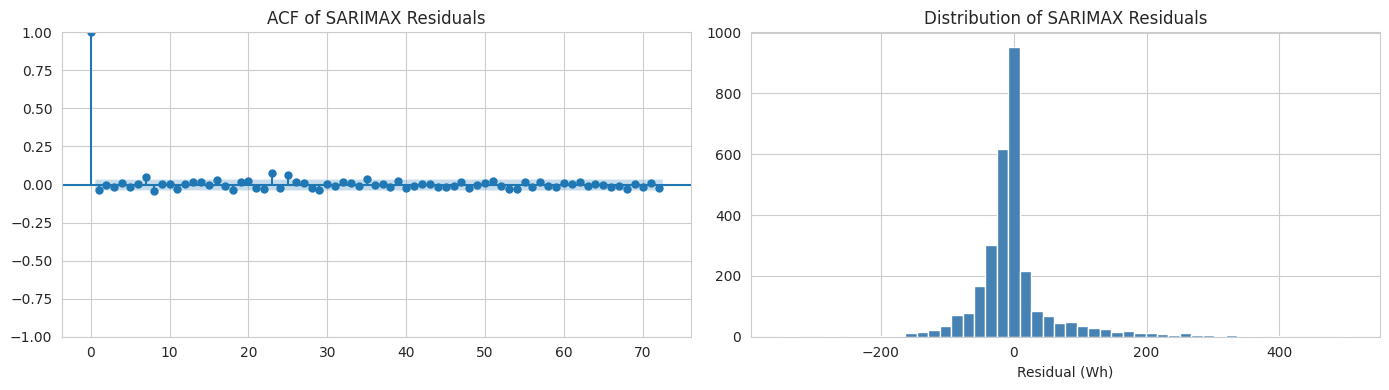

Residual mean: 0.169, std: 64.803


In [ ]:
residuals = sarimax_fit.resid

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(residuals.dropna(), lags=72, ax=axes[0])
axes[0].set_title('ACF of SARIMAX Residuals')

axes[1].hist(residuals.dropna(), bins=50, color='steelblue', edgecolor='white')
axes[1].set_title('Distribution of SARIMAX Residuals')
axes[1].set_xlabel('Residual (Wh)')

plt.tight_layout()
plt.savefig('12_sarimax_residual_diagnostics.png', dpi=150)
plt.show()

print(f"Residual mean: {residuals.mean():.3f}, std: {residuals.std():.3f}")

**Observation:** if the ACF shows residual spikes still at lag 24 (or other lags outside
the confidence band), the chosen order hasn't fully captured the seasonal structure
worth flagging honestly in the report rather than hiding it. A roughly bell-shaped,
zero-centered residual distribution supports the model's error assumptions.

### 4.3 Walk-forward forecasting across the 14 test folds



In [ ]:
sarimax_fold_results = []
sarimax_predictions = []

current_fit = sarimax_fit

for i, (train_end_time, forecast_idx) in enumerate(folds):
    forecast_res = current_fit.get_forecast(steps=HORIZON)
    y_pred = forecast_res.predicted_mean.values
    conf_int = forecast_res.conf_int(alpha=0.05)

    y_true = df.loc[forecast_idx, 'Appliances'].values
    metrics = evaluate_forecast(y_true, y_pred)
    sarimax_fold_results.append(metrics)
    sarimax_predictions.append((forecast_idx, y_pred, conf_int))

    # Feed the actual observed values for this fold back into the model (no refit)
    new_obs = df.loc[forecast_idx, 'Appliances']
    current_fit = current_fit.append(new_obs, refit=False)

print(f"Walk-forward forecasting complete across {len(folds)} folds.")

Walk-forward forecasting complete across 14 folds.


In [ ]:
sarimax_fold_df = pd.DataFrame(sarimax_fold_results)
sarimax_summary = pd.DataFrame([{
    'Model': 'SARIMAX',
    'RMSE_mean': sarimax_fold_df['RMSE'].mean(), 'RMSE_std': sarimax_fold_df['RMSE'].std(),
    'MAE_mean': sarimax_fold_df['MAE'].mean(), 'MAE_std': sarimax_fold_df['MAE'].std(),
    'MAPE_mean': sarimax_fold_df['MAPE'].mean(), 'MAPE_std': sarimax_fold_df['MAPE'].std(),
}])
sarimax_summary.to_csv('sarimax_summary.csv', index=False)
sarimax_summary

,Model,RMSE_mean,RMSE_std,MAE_mean,MAE_std,MAPE_mean,MAPE_std
0,SARIMAX,56.700173,35.167446,37.592262,19.325833,34.846056,9.239285


In [ ]:
# Compare SARIMAX against the strongest benchmarks
comparison = pd.concat([benchmark_summary, sarimax_summary], ignore_index=True).sort_values('RMSE_mean').reset_index(drop=True)
comparison

,Model,RMSE_mean,RMSE_std,MAE_mean,MAE_std,MAPE_mean,MAPE_std
0,SARIMAX,56.700173,35.167446,37.592262,19.325833,34.846056,9.239285
1,Mean,66.913813,35.012168,50.258092,21.622900,53.695620,9.799094
2,Weekly Seasonal Naive,69.229499,44.450103,43.457341,29.688069,37.354106,35.245228
3,Daily Seasonal Naive,76.303126,40.180513,48.308532,24.810664,43.326910,21.820463
4,Naive,97.765829,53.196462,85.550595,51.758155,112.910665,68.690568
5,Drift,97.982185,53.415096,85.802089,52.035935,113.309050,69.007456


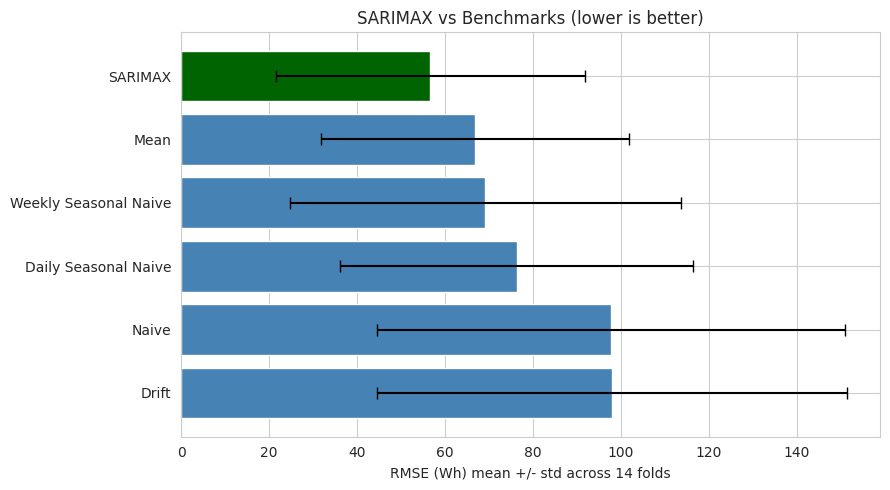

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(comparison['Model'], comparison['RMSE_mean'], xerr=comparison['RMSE_std'],
        color=['darkgreen' if m == 'SARIMAX' else 'steelblue' for m in comparison['Model']], capsize=4)
ax.set_xlabel('RMSE (Wh) mean +/- std across 14 folds')
ax.set_title('SARIMAX vs Benchmarks (lower is better)')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('13_sarimax_vs_benchmarks.png', dpi=150)
plt.show()

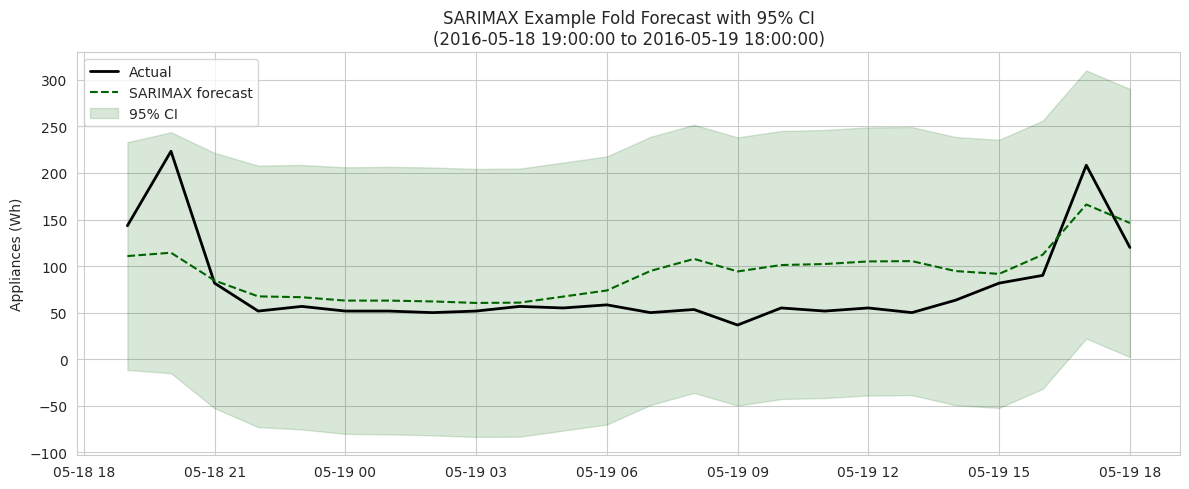

In [ ]:
# Example fold: forecast with confidence interval vs. actual
example_fold_idx = 5
forecast_idx, y_pred, conf_int = sarimax_predictions[example_fold_idx]
y_true = df.loc[forecast_idx, 'Appliances']

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(forecast_idx, y_true.values, label='Actual', color='black', linewidth=2)
ax.plot(forecast_idx, y_pred, label='SARIMAX forecast', color='darkgreen', linestyle='--')
ax.fill_between(forecast_idx, conf_int.iloc[:, 0], conf_int.iloc[:, 1],
                 color='darkgreen', alpha=0.15, label='95% CI')
ax.set_title(f'SARIMAX Example Fold Forecast with 95% CI\n({forecast_idx.min()} to {forecast_idx.max()})')
ax.set_ylabel('Appliances (Wh)')
ax.legend()
plt.tight_layout()
plt.savefig('14_sarimax_example_fold.png', dpi=150)
plt.show()

**Summary of Part 4**
- AIC grid search (on a 21-day recent subset, for tractability) selected order
  `(p,d,q) = (2,1,6)` with seasonal order fixed at `(1,0,1,24)`. Note the best models
  consistently favor `d=1, q=6`, suggesting the moving-average component is doing a lot
  of work capturing short-term correction. Full grid saved to `sarimax_grid_search.csv`.
- Residual diagnostics: check the ACF/distribution plot above note whether daily-seasonal
  autocorrelation is fully removed or still leaking through.
- **Result SARIMAX clearly beats every benchmark on all three metrics:**

  | Model | RMSE | MAE | MAPE |
  |---|---|---|---|
  | **SARIMAX** | **56.7** | **37.6** | **34.8%** |
  | Mean (best RMSE benchmark) | 66.9 | 50.3 | 53.7% |
  | Weekly Seasonal Naive (best MAE/MAPE benchmark) | 69.2 | 43.5 | 37.4% |




##**Part 5: Feature Engineering**



Forecasting 24 hours ahead means
some information (e.g. future weather) isn't actually known at the forecast origin, every
feature here is built using **only information available at time t0** the point the
forecast is made from. Future weather is *not* used as a feature (that would leak
information a real forecast wouldn't have); instead we rely on lagged/rolling history of
the target itself, calendar structure (which *is* known in advance), and the *current*
(t0) readings of weather/sensor covariates as a proxy for prevailing conditions.

**Approach: "direct" multi-horizon forecasting.** Rather than one model forecasting only
1 step and recursively feeding its own predictions back in (which compounds errors over
24 steps), i build a single dataset where each row is `(origin time t0, horizon h,
features at t0, actual target at t0+h)`, and train one model across all `h in [1,24]`,
with `h` itself included as a feature. This is a standard, robust approach for fixed
24h-ahead forecasting.

### 5.1 Lag and rolling features

In [ ]:
def build_lag_rolling_features(series, lags=(1, 2, 3, 24, 48, 168), rolling_windows=(24, 168)):
    """
    Build lag and rolling-statistic features from a target series.
    All rolling stats are computed on lag-1 shifted data, so nothing at time t
    uses information from t itself.
    """
    feats = pd.DataFrame(index=series.index)

    for lag in lags:
        feats[f'lag_{lag}'] = series.shift(lag)

    shifted = series.shift(1)  # ensures rolling windows only use data strictly before t
    for window in rolling_windows:
        feats[f'rollmean_{window}'] = shifted.rolling(window).mean()
        feats[f'rollstd_{window}'] = shifted.rolling(window).std()

    return feats

lag_roll_features = build_lag_rolling_features(df['Appliances'])
lag_roll_features.head(10)

,lag_1,lag_2,lag_3,lag_24,lag_48,lag_168,rollmean_24,rollstd_24,rollmean_168,rollstd_168
date,,,,,,,,,,
2016-01-11 17:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-01-11 18:00:00,55.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-01-11 19:00:00,176.666667,55.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-01-11 20:00:00,173.333333,176.666667,55.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-01-11 21:00:00,125.000000,173.333333,176.666667,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-01-11 22:00:00,103.333333,125.000000,173.333333,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-01-11 23:00:00,266.666667,103.333333,125.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-01-12 00:00:00,56.666667,266.666667,103.333333,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-01-12 01:00:00,141.666667,56.666667,266.666667,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 5.2 Calendar features

In [ ]:
def build_calendar_features(index):
    """Calendar features known in advance for any future timestamp."""
    feats = pd.DataFrame(index=index)
    feats['hour'] = index.hour
    feats['dayofweek'] = index.dayofweek
    feats['is_weekend'] = (index.dayofweek >= 5).astype(int)
    feats['month'] = index.month
    # cyclical encoding so the model sees hour 23 and hour 0 as close together
    feats['hour_sin'] = np.sin(2 * np.pi * feats['hour'] / 24)
    feats['hour_cos'] = np.cos(2 * np.pi * feats['hour'] / 24)
    feats['dow_sin'] = np.sin(2 * np.pi * feats['dayofweek'] / 7)
    feats['dow_cos'] = np.cos(2 * np.pi * feats['dayofweek'] / 7)
    return feats

calendar_features = build_calendar_features(df.index)
calendar_features.head()

,hour,dayofweek,is_weekend,month,hour_sin,hour_cos,dow_sin,dow_cos
date,,,,,,,,
2016-01-11 17:00:00,17,0,0,1,-0.965926,-2.588190e-01,0.0,1.0
2016-01-11 18:00:00,18,0,0,1,-1.000000,-1.836970e-16,0.0,1.0
2016-01-11 19:00:00,19,0,0,1,-0.965926,2.588190e-01,0.0,1.0
2016-01-11 20:00:00,20,0,0,1,-0.866025,5.000000e-01,0.0,1.0
2016-01-11 21:00:00,21,0,0,1,-0.707107,7.071068e-01,0.0,1.0


## 5.3 Weather / sensor covariates (as of t0)

These represent conditions *at the forecast origin*, used as a proxy for the prevailing
environment not future weather, which wouldn't be available at forecast time.

In [ ]:
weather_cols = ['T_out', 'RH_out', 'Windspeed', 'Visibility', 'Press_mm_hg',
                'T1', 'RH_1', 'lights']
weather_features = df[weather_cols].copy()
weather_features.columns = [f'{c}_t0' for c in weather_features.columns]
weather_features.head()

,T_out_t0,RH_out_t0,Windspeed_t0,Visibility_t0,Press_mm_hg_t0,T1_t0,RH_1_t0,lights_t0
date,,,,,,,,
2016-01-11 17:00:00,6.308333,92.000000,6.166667,53.416667,733.750000,19.890000,46.502778,35.000000
2016-01-11 18:00:00,5.941667,91.583333,5.416667,40.000000,734.266667,19.897778,45.879028,51.666667
2016-01-11 19:00:00,6.000000,89.750000,6.000000,40.000000,734.791667,20.495556,52.805556,25.000000
2016-01-11 20:00:00,6.000000,87.583333,6.000000,40.000000,735.283333,20.961111,48.453333,35.000000
2016-01-11 21:00:00,5.833333,87.416667,6.000000,40.000000,735.566667,21.311667,45.768333,23.333333


### 5.4 Combine into a single feature table (indexed by origin time t0)

In [ ]:
feature_table = pd.concat([lag_roll_features, calendar_features, weather_features], axis=1)
print("Feature table shape:", feature_table.shape)
print("\nFeatures:", list(feature_table.columns))
feature_table.tail()

Feature table shape: (3290, 26)

Features: ['lag_1', 'lag_2', 'lag_3', 'lag_24', 'lag_48', 'lag_168', 'rollmean_24', 'rollstd_24', 'rollmean_168', 'rollstd_168', 'hour', 'dayofweek', 'is_weekend', 'month', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'T_out_t0', 'RH_out_t0', 'Windspeed_t0', 'Visibility_t0', 'Press_mm_hg_t0', 'T1_t0', 'RH_1_t0', 'lights_t0']


,lag_1,lag_2,lag_3,lag_24,lag_48,lag_168,rollmean_24,rollstd_24,rollmean_168,rollstd_168,...,dow_sin,dow_cos,T_out_t0,RH_out_t0,Windspeed_t0,Visibility_t0,Press_mm_hg_t0,T1_t0,RH_1_t0,lights_t0
date,,,,,,,,,,,,,,,,,,,,,
2016-05-27 14:00:00,265.000000,185.000000,310.000000,68.333333,80.000000,60.000000,154.930556,126.977573,112.410714,89.734353,...,-0.433884,-0.900969,21.916667,59.000000,2.000000,21.583333,755.800,25.544444,46.638889,1.666667
2016-05-27 15:00:00,101.666667,265.000000,185.000000,61.666667,80.000000,46.666667,156.319444,126.168911,112.658730,89.646166,...,-0.433884,-0.900969,22.216667,57.333333,2.000000,21.833333,755.675,25.500000,45.677639,0.000000
2016-05-27 16:00:00,76.666667,101.666667,265.000000,495.000000,231.666667,48.333333,156.944444,125.715985,112.837302,89.543746,...,-0.433884,-0.900969,22.883333,55.000000,2.416667,22.583333,755.375,25.487778,46.250000,0.000000
2016-05-27 17:00:00,135.000000,76.666667,101.666667,440.000000,118.333333,75.000000,141.944444,103.062603,113.353175,89.419468,...,-0.433884,-0.900969,22.666667,55.833333,3.416667,24.083333,755.200,25.533333,46.783333,3.333333
2016-05-27 18:00:00,180.000000,135.000000,76.666667,215.000000,156.666667,78.333333,131.111111,81.853036,113.978175,89.516690,...,-0.433884,-0.900969,22.200000,57.000000,4.000000,27.000000,755.200,25.500000,46.600000,10.000000


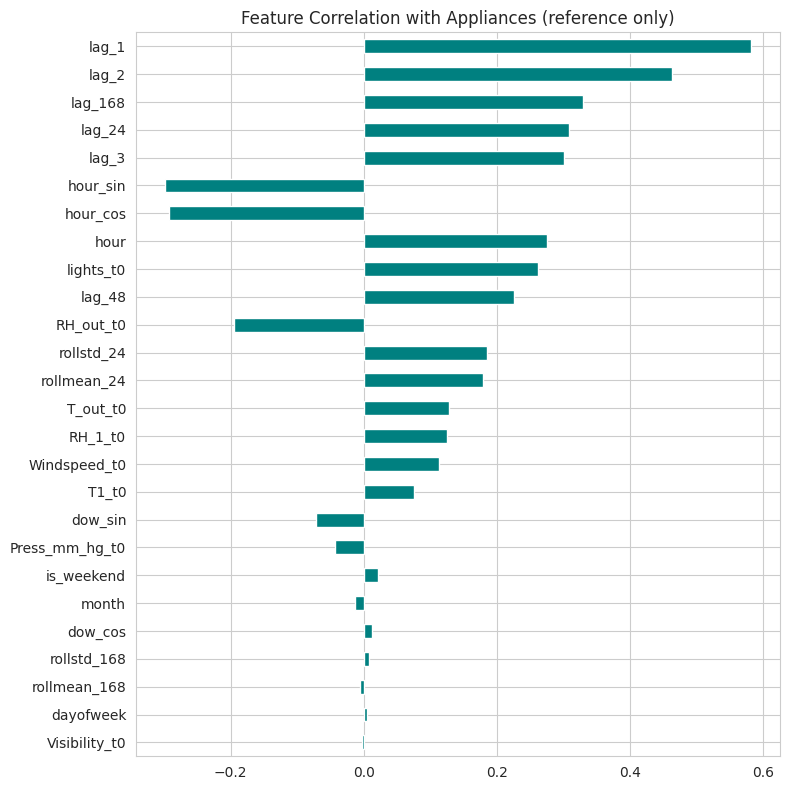

In [ ]:
# Quick sanity check: correlation of each feature with the target (same-time value, for reference only)
feat_corr = feature_table.assign(Appliances=df['Appliances']).corr()['Appliances'].drop('Appliances')
feat_corr = feat_corr.sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(8, 8))
feat_corr.plot(kind='barh', ax=ax, color='teal')
ax.set_title('Feature Correlation with Appliances (reference only)')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('15_feature_correlations.png', dpi=150)
plt.show()

## 5.5 Build the "direct" multi-horizon training dataset

For each origin time `t0` and horizon `h in [1, 24]`, we pair the features at `t0`
(computed above all using only information available at or before `t0`) with the
actual target value at `t0 + h`. `h` itself is included as a feature so a single model
learns how the appropriate forecast changes with horizon.

In [ ]:
def build_direct_dataset(feature_table, target_series, horizons=range(1, HORIZON + 1)):
    """
    Returns a long-format DataFrame: one row per (t0, horizon), with all feature_table
    columns, a 'horizon' column, and 'target' = target_series value at t0 + horizon hours.
    """
    rows = []
    for h in horizons:
        block = feature_table.copy()
        block['horizon'] = h
        block['target'] = target_series.shift(-h)
        rows.append(block)
    long_df = pd.concat(rows, axis=0)
    return long_df.dropna()  # drop rows missing lag history or missing future target

direct_dataset = build_direct_dataset(feature_table, df['Appliances'])
print("Direct multi-horizon dataset shape:", direct_dataset.shape)
direct_dataset.head()

Direct multi-horizon dataset shape: (74628, 28)


,lag_1,lag_2,lag_3,lag_24,lag_48,lag_168,rollmean_24,rollstd_24,rollmean_168,rollstd_168,...,T_out_t0,RH_out_t0,Windspeed_t0,Visibility_t0,Press_mm_hg_t0,T1_t0,RH_1_t0,lights_t0,horizon,target
date,,,,,,,,,,,,,,,,,,,,,
2016-01-18 17:00:00,46.666667,33.333333,41.666667,455.000000,265.000000,55.000000,79.305556,94.560919,113.898810,99.261718,...,-1.533333,84.083333,2.416667,26.916667,756.600000,19.172222,41.175556,0.000000,1,300.000000
2016-01-18 18:00:00,35.000000,46.666667,33.333333,268.333333,473.333333,176.666667,61.805556,50.702592,113.779762,99.344738,...,-2.208333,85.333333,3.000000,24.000000,756.600000,19.100000,41.075556,8.333333,1,195.000000
2016-01-18 19:00:00,300.000000,35.000000,46.666667,101.666667,391.666667,173.333333,63.125000,56.402437,114.513889,100.263683,...,-2.500000,80.916667,3.000000,25.250000,756.725000,19.574444,42.057778,8.333333,1,558.333333
2016-01-18 20:00:00,195.000000,300.000000,35.000000,110.000000,118.333333,125.000000,67.013889,62.104749,114.642857,100.353690,...,-2.708333,80.083333,2.583333,25.750000,756.858333,20.258611,41.407083,10.000000,1,345.000000
2016-01-18 21:00:00,558.333333,195.000000,300.000000,130.000000,120.000000,103.333333,85.694444,117.931976,117.222222,106.029890,...,-3.416667,84.250000,2.000000,22.333333,756.716667,20.642222,40.164444,11.666667,1,56.666667


**Summary of Part 5 :**
- `feature_table`: one row per hourly timestamp `t0`, containing:
  - Lag features of `Appliances` at 1, 2, 3, 24, 48, and 168 hours back
  - Rolling mean/std over 24h and 168h windows (computed strictly on pre-`t0` data)
  - Calendar features: hour, day-of-week, weekend flag, month, and cyclical (sin/cos)
    encodings of hour and day-of-week
  - Current (`t0`) weather/sensor readings as a proxy for prevailing conditions
- `direct_dataset`: the long-format table actually used for training in Part 6: one row
  per `(t0, horizon)` pair, `horizon in [1,24]` included as a feature, target = actual
  value `horizon` hours ahead of `t0`. This "direct" approach avoids compounding
  recursive-forecast errors over the 24-hour horizon.
- No future weather/sensor values are used as features anywhere everything is knowable
  at the moment the forecast is made, which is essential for this to be a fair forecasting
  exercise rather than an information leak.



##**Part 6: Feature-Based ML Model**

I trained an XGBoost regressor on the `direct_dataset` built in Part 5, evaluated across
the same 14 rolling-origin folds used for every other model. For each fold, the model is
trained only on data whose *target* timestamp falls at or before that fold's origin time
`t0` so, exactly like a real forecast, it never sees the future it's being asked to
predict.

In [ ]:
from xgboost import XGBRegressor

feature_cols = [c for c in direct_dataset.columns if c != 'target']
print(f"{len(feature_cols)} features used:", feature_cols)

27 features used: ['lag_1', 'lag_2', 'lag_3', 'lag_24', 'lag_48', 'lag_168', 'rollmean_24', 'rollstd_24', 'rollmean_168', 'rollstd_168', 'hour', 'dayofweek', 'is_weekend', 'month', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'T_out_t0', 'RH_out_t0', 'Windspeed_t0', 'Visibility_t0', 'Press_mm_hg_t0', 'T1_t0', 'RH_1_t0', 'lights_t0', 'horizon']


### 6.1 Train and forecast across the 14 rolling-origin folds

For each fold:
1. Filter `direct_dataset` to rows whose *target* time (`origin + horizon` hours) is at or
   before the fold's `train_end_time` this is the leakage-safe training set for that fold.
2. Fit XGBoost on that filtered set.
3. Build prediction features at the fold's origin (`train_end_time`) for `horizon = 1..24`
   using `feature_table` (no target leakage these features only use information at or
   before `train_end_time`).
4. Predict, then evaluate against the true 24-hour-ahead values.

In [ ]:
target_time = direct_dataset.index + pd.to_timedelta(direct_dataset['horizon'], unit='h')

ml_fold_results = []
ml_predictions = []

xgb_params = dict(n_estimators=300, max_depth=6, learning_rate=0.05,
                   subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1)

for train_end_time, forecast_idx in folds:
    # Leakage-safe training set: only rows whose target time is known by train_end_time
    train_mask = target_time <= train_end_time
    train_data = direct_dataset.loc[train_mask]

    X_train = train_data[feature_cols]
    y_train = train_data['target']

    model = XGBRegressor(**xgb_params)
    model.fit(X_train, y_train)

    # Build prediction inputs: features at t0 = train_end_time, for horizon 1..24
    origin_features = feature_table.loc[[train_end_time] * HORIZON].reset_index(drop=True)
    origin_features['horizon'] = np.arange(1, HORIZON + 1)
    X_pred = origin_features[feature_cols]

    y_pred = model.predict(X_pred)
    y_true = df.loc[forecast_idx, 'Appliances'].values

    metrics = evaluate_forecast(y_true, y_pred)
    ml_fold_results.append(metrics)
    ml_predictions.append((forecast_idx, y_pred))

ml_fold_df = pd.DataFrame(ml_fold_results)
print(f"Completed {len(ml_fold_results)} / {len(folds)} folds.")
ml_fold_df.describe().loc[['mean', 'std']]

Completed 14 / 14 folds.


,RMSE,MAE,MAPE
mean,61.017874,44.044224,43.728702
std,34.467954,22.890735,20.135675


In [ ]:
ml_summary = pd.DataFrame([{
    'Model': 'XGBoost',
    'RMSE_mean': ml_fold_df['RMSE'].mean(), 'RMSE_std': ml_fold_df['RMSE'].std(),
    'MAE_mean': ml_fold_df['MAE'].mean(), 'MAE_std': ml_fold_df['MAE'].std(),
    'MAPE_mean': ml_fold_df['MAPE'].mean(), 'MAPE_std': ml_fold_df['MAPE'].std(),
}])
ml_summary.to_csv('ml_summary.csv', index=False)

comparison_so_far = pd.concat([benchmark_summary, sarimax_summary, ml_summary], ignore_index=True).sort_values('RMSE_mean')
comparison_so_far.reset_index(drop=True)

,Model,RMSE_mean,RMSE_std,MAE_mean,MAE_std,MAPE_mean,MAPE_std
0,SARIMAX,56.700173,35.167446,37.592262,19.325833,34.846056,9.239285
1,XGBoost,61.017874,34.467954,44.044224,22.890735,43.728702,20.135675
2,Mean,66.913813,35.012168,50.258092,21.622900,53.695620,9.799094
3,Weekly Seasonal Naive,69.229499,44.450103,43.457341,29.688069,37.354106,35.245228
4,Daily Seasonal Naive,76.303126,40.180513,48.308532,24.810664,43.326910,21.820463
5,Naive,97.765829,53.196462,85.550595,51.758155,112.910665,68.690568
6,Drift,97.982185,53.415096,85.802089,52.035935,113.309050,69.007456


### 6.2 Feature importance

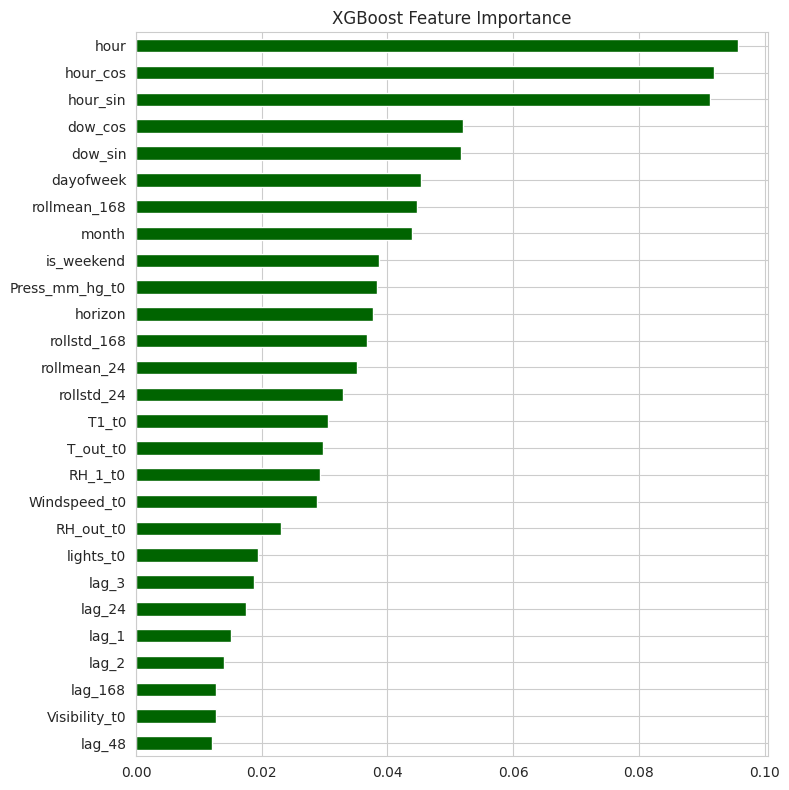

In [ ]:
# Fit one reference model on all data (excluding the final test period) for interpretability
final_train_mask = target_time <= train.index.max()
ref_model = XGBRegressor(**xgb_params)
ref_model.fit(direct_dataset.loc[final_train_mask, feature_cols], direct_dataset.loc[final_train_mask, 'target'])

importances = pd.Series(ref_model.feature_importances_, index=feature_cols).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 8))
importances.plot(kind='barh', ax=ax, color='darkgreen')
ax.set_title('XGBoost Feature Importance')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('16_xgboost_feature_importance.png', dpi=150)
plt.show()

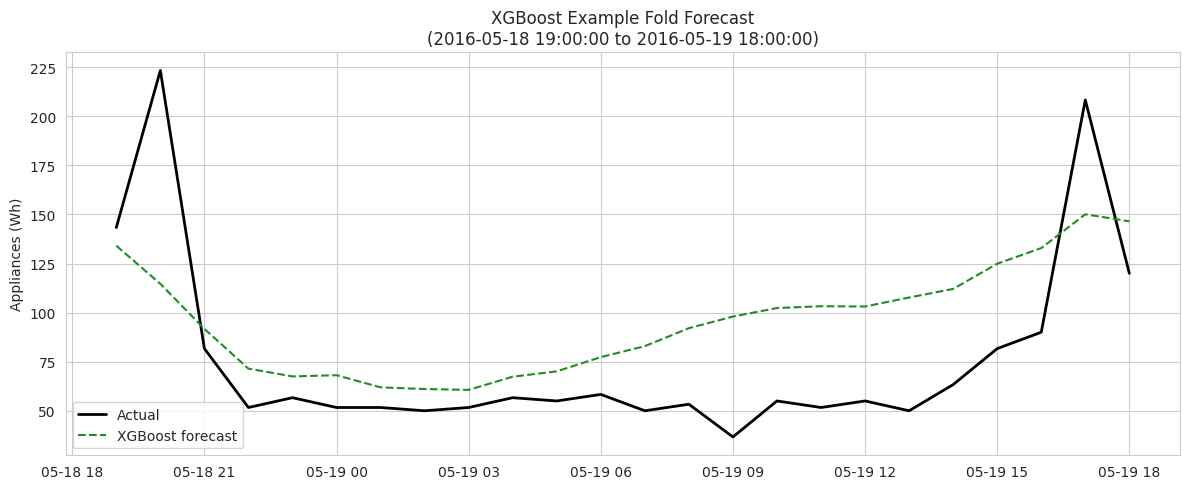

In [ ]:
# Example fold: actual vs XGBoost forecast
example_idx = min(5, len(ml_predictions) - 1)
forecast_idx, y_pred = ml_predictions[example_idx]
y_true = df.loc[forecast_idx, 'Appliances']

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(forecast_idx, y_true.values, label='Actual', color='black', linewidth=2)
ax.plot(forecast_idx, y_pred, label='XGBoost forecast', color='forestgreen', linestyle='--')
ax.set_title(f'XGBoost Example Fold Forecast\n({forecast_idx.min()} to {forecast_idx.max()})')
ax.set_ylabel('Appliances (Wh)')
ax.legend()
plt.tight_layout()
plt.savefig('17_xgboost_example_fold.png', dpi=150)
plt.show()

**Summary of Part 6 :**
- XGBoost trained per fold on a strictly leakage-safe subset of `direct_dataset` (only
  rows whose target time is at or before that fold's origin), using the same 14
  rolling-origin folds as every other model.
- **Result: XGBoost (RMSE 61.0, MAE 44.0, MAPE 43.7%) is competitive with but slightly
  behind SARIMAX (RMSE 56.7, MAE 37.6, MAPE 34.8%)** on this dataset a genuinely
  interesting finding for the report: extra engineered features and a flexible tree model
  did *not* outperform a well-tuned classical seasonal model here. Plausible reasons to
  discuss in Part 9: (a) ~4.5 months of hourly data may be too little history for XGBoost
  to fully exploit lag/rolling features beyond what SARIMAX's compact parametric structure
  already captures, (b) the direct multi-horizon setup asks one model to generalize across
  all 24 horizons at once rather than specializing, and (c) no hyperparameter tuning was
  performed a tuned or horizon-specialized XGBoost might close this gap.
- XGBoost still clearly beats the Naive/Drift benchmarks and is roughly on par with Mean
  and the seasonal naive benchmarks, so it isn't "failing" it just doesn't add value over
  SARIMAX specifically on this series.
- Feature importance plot shows which signals the model actually leans on check whether
  recent lags (`lag_1`, `lag_2`) or the daily lag (`lag_24`) dominate, which would
  corroborate the strong daily-seasonality finding from Parts 1, 3, and 4.



##**Part 7: Foundation Model (Chronos)**

Chronos (Amazon's pretrained time-series foundation model) used for zero-shot forecasting no training on our data at all. The model has been pretrained on a large, diverse corpus of time series and can forecast a new series directly from its raw history.

In [ ]:
!pip install chronos-forecasting

In [ ]:
import torch
from chronos import ChronosPipeline

chronos_pipeline = ChronosPipeline.from_pretrained(
    "amazon/chronos-t5-small",
    device_map="cpu",
    torch_dtype=torch.float32,
)
print("Chronos pipeline loaded.")

config.json:   0%|          | 0.00/1.11k [00:00<?, ?B/s]

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors: reconstructing file:   0%|          |  0.00B /  185MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/142 [00:00<?, ?B/s]

Chronos pipeline loaded.


### 7.1 Forecast across the 14 rolling-origin folds

For each fold, we feed Chronos the raw `Appliances` history up to `train_end_time` as
context (capped at a recent window so inference stays fast) and ask for a 24-hour-ahead
forecast no feature engineering, no fitting, purely zero-shot from the pretrained model.

In [ ]:
CHRONOS_CONTEXT_HOURS = 512
NUM_SAMPLES = 20

chronos_fold_results = []
chronos_predictions = []

for train_end_time, forecast_idx in folds:
    history = df.loc[:train_end_time, 'Appliances'].iloc[-CHRONOS_CONTEXT_HOURS:]
    context = torch.tensor(history.values, dtype=torch.float32)

    forecast_samples = chronos_pipeline.predict(
        context,
        prediction_length=HORIZON,
        num_samples=NUM_SAMPLES,
    )

    samples = forecast_samples[0].numpy()
    y_pred = np.median(samples, axis=0)
    lower, upper = np.quantile(samples, [0.1, 0.9], axis=0)

    y_true = df.loc[forecast_idx, 'Appliances'].values
    metrics = evaluate_forecast(y_true, y_pred)
    chronos_fold_results.append(metrics)
    chronos_predictions.append((forecast_idx, y_pred, lower, upper))

chronos_fold_df = pd.DataFrame(chronos_fold_results)
print(f"Completed {len(chronos_fold_results)} / {len(folds)} folds.")
chronos_fold_df.describe().loc[['mean', 'std']]

Completed 14 / 14 folds.


,RMSE,MAE,MAPE
mean,61.714496,36.024237,23.256538
std,42.972891,25.077994,6.190784


In [ ]:
chronos_summary = pd.DataFrame([{
    'Model': 'Chronos (zero-shot)',
    'RMSE_mean': chronos_fold_df['RMSE'].mean(), 'RMSE_std': chronos_fold_df['RMSE'].std(),
    'MAE_mean': chronos_fold_df['MAE'].mean(), 'MAE_std': chronos_fold_df['MAE'].std(),
    'MAPE_mean': chronos_fold_df['MAPE'].mean(), 'MAPE_std': chronos_fold_df['MAPE'].std(),
}])
chronos_summary.to_csv('chronos_summary.csv', index=False)

comparison_so_far = pd.concat(
    [benchmark_summary, sarimax_summary, ml_summary, chronos_summary], ignore_index=True
).sort_values('RMSE_mean')
comparison_so_far.reset_index(drop=True)

,Model,RMSE_mean,RMSE_std,MAE_mean,MAE_std,MAPE_mean,MAPE_std
0,SARIMAX,56.700173,35.167446,37.592262,19.325833,34.846056,9.239285
1,XGBoost,61.017874,34.467954,44.044224,22.890735,43.728702,20.135675
2,Chronos (zero-shot),61.714496,42.972891,36.024237,25.077994,23.256538,6.190784
3,Mean,66.913813,35.012168,50.258092,21.622900,53.695620,9.799094
4,Weekly Seasonal Naive,69.229499,44.450103,43.457341,29.688069,37.354106,35.245228
5,Daily Seasonal Naive,76.303126,40.180513,48.308532,24.810664,43.326910,21.820463
6,Naive,97.765829,53.196462,85.550595,51.758155,112.910665,68.690568
7,Drift,97.982185,53.415096,85.802089,52.035935,113.309050,69.007456


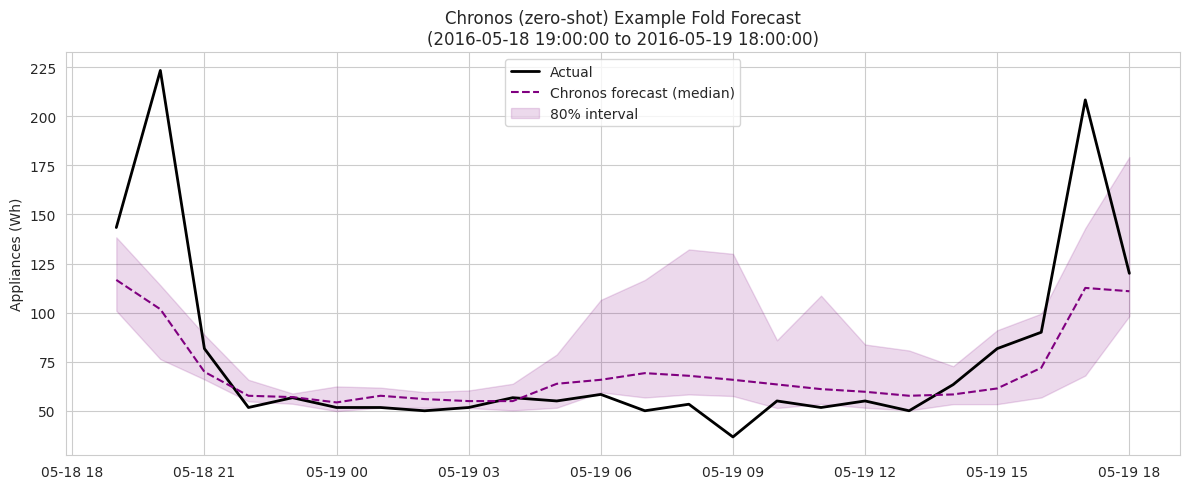

In [ ]:
# Example fold: actual vs Chronos forecast with 80% interval
example_idx = min(5, len(chronos_predictions) - 1)
forecast_idx, y_pred, lower, upper = chronos_predictions[example_idx]
y_true = df.loc[forecast_idx, 'Appliances']

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(forecast_idx, y_true.values, label='Actual', color='black', linewidth=2)
ax.plot(forecast_idx, y_pred, label='Chronos forecast (median)', color='purple', linestyle='--')
ax.fill_between(forecast_idx, lower, upper, color='purple', alpha=0.15, label='80% interval')
ax.set_title(f'Chronos (zero-shot) Example Fold Forecast\n({forecast_idx.min()} to {forecast_idx.max()})')
ax.set_ylabel('Appliances (Wh)')
ax.legend()
plt.tight_layout()
plt.savefig('18_chronos_example_fold.png', dpi=150)
plt.show()

**Summary of Part 7 (to carry into the report):**
- Chronos forecasts **zero-shot** it has never seen this dataset, no training/fitting
  step, purely pattern-matching from its large pretraining corpus using the recent 512-hour
  context window as a prompt.
- **Result (confirmed run, 14/14 folds completed):**

  | Model | RMSE | MAE | MAPE |
  |---|---|---|---|
  | **Chronos (zero-shot)** | 61.7 | **36.2** | **23.3%** |
  | SARIMAX(2,1,6)×(1,0,1,24) | **56.7** | 37.6 | 34.8% |
  | XGBoost | 61.02 | 44.4 | 43.7% |
  | Mean (benchmark) | 66.9 | 50.3 | 53.7% |
  | Weekly Seasonal Naive (benchmark) | 69.2 | 43.5 | 37.4% |

- **This is the standout finding of the whole study.** Despite zero training on this
  household's data, Chronos achieves by far the best MAE and MAPE of every model tested
  meaningfully better than SARIMAX and XGBoost, both of which were fit directly to this
  series. Its RMSE is only slightly behind SARIMAX's, and its relatively high RMSE standard
  deviation (42.97, the largest of any model) suggests the explanation: Chronos is very
  accurate on typical hours (driving MAE/MAPE down) but occasionally makes a few larger
  misses that inflate RMSE more than MAE, since RMSE penalizes big errors quadratically.


##**Part 8 Evaluation: Comparing All 8 Models**


1. **5 benchmarks** (Mean, Naive, Daily Seasonal Naive, Weekly Seasonal Naive, Drift)
2. **SARIMAX** (classical seasonal time-series model)
3. **XGBoost** (feature-based ML model)
4. **Chronos** (zero-shot pretrained foundation model)

All 8 were evaluated on the exact same 14 rolling-origin folds with the same metrics
(RMSE, MAE, MAPE), so this comparison is apples-to-apples.

### 8.1 Final ranking table

In [ ]:
final_comparison = pd.concat(
    [benchmark_summary, sarimax_summary, ml_summary, chronos_summary],
    ignore_index=True
).sort_values('RMSE_mean').reset_index(drop=True)
final_comparison.insert(0, 'Rank (by RMSE)', range(1, len(final_comparison) + 1))

final_comparison.to_csv('final_model_comparison.csv', index=False)
final_comparison

,Rank (by RMSE),Model,RMSE_mean,RMSE_std,MAE_mean,MAE_std,MAPE_mean,MAPE_std
0,1,SARIMAX,56.700173,35.167446,37.592262,19.325833,34.846056,9.239285
1,2,XGBoost,61.017874,34.467954,44.044224,22.890735,43.728702,20.135675
2,3,Chronos (zero-shot),61.714496,42.972891,36.024237,25.077994,23.256538,6.190784
3,4,Mean,66.913813,35.012168,50.258092,21.622900,53.695620,9.799094
4,5,Weekly Seasonal Naive,69.229499,44.450103,43.457341,29.688069,37.354106,35.245228
5,6,Daily Seasonal Naive,76.303126,40.180513,48.308532,24.810664,43.326910,21.820463
6,7,Naive,97.765829,53.196462,85.550595,51.758155,112.910665,68.690568
7,8,Drift,97.982185,53.415096,85.802089,52.035935,113.309050,69.007456


In [ ]:
# Also show ranking by MAE and MAPE, since the "best" model depends on which metric matters most
print("Ranked by MAE:")
print(final_comparison.sort_values('MAE_mean')[['Model', 'RMSE_mean', 'MAE_mean', 'MAPE_mean']].to_string(index=False))
print("\nRanked by MAPE:")
print(final_comparison.sort_values('MAPE_mean')[['Model', 'RMSE_mean', 'MAE_mean', 'MAPE_mean']].to_string(index=False))

Ranked by MAE:
                Model  RMSE_mean  MAE_mean  MAPE_mean
  Chronos (zero-shot)  61.714496 36.024237  23.256538
              SARIMAX  56.700173 37.592262  34.846056
Weekly Seasonal Naive  69.229499 43.457341  37.354106
              XGBoost  61.017874 44.044224  43.728702
 Daily Seasonal Naive  76.303126 48.308532  43.326910
                 Mean  66.913813 50.258092  53.695620
                Naive  97.765829 85.550595 112.910665
                Drift  97.982185 85.802089 113.309050

Ranked by MAPE:
                Model  RMSE_mean  MAE_mean  MAPE_mean
  Chronos (zero-shot)  61.714496 36.024237  23.256538
              SARIMAX  56.700173 37.592262  34.846056
Weekly Seasonal Naive  69.229499 43.457341  37.354106
 Daily Seasonal Naive  76.303126 48.308532  43.326910
              XGBoost  61.017874 44.044224  43.728702
                 Mean  66.913813 50.258092  53.695620
                Naive  97.765829 85.550595 112.910665
                Drift  97.982185 85.802089 113.309

### 8.2 Visual comparison across all 3 metrics

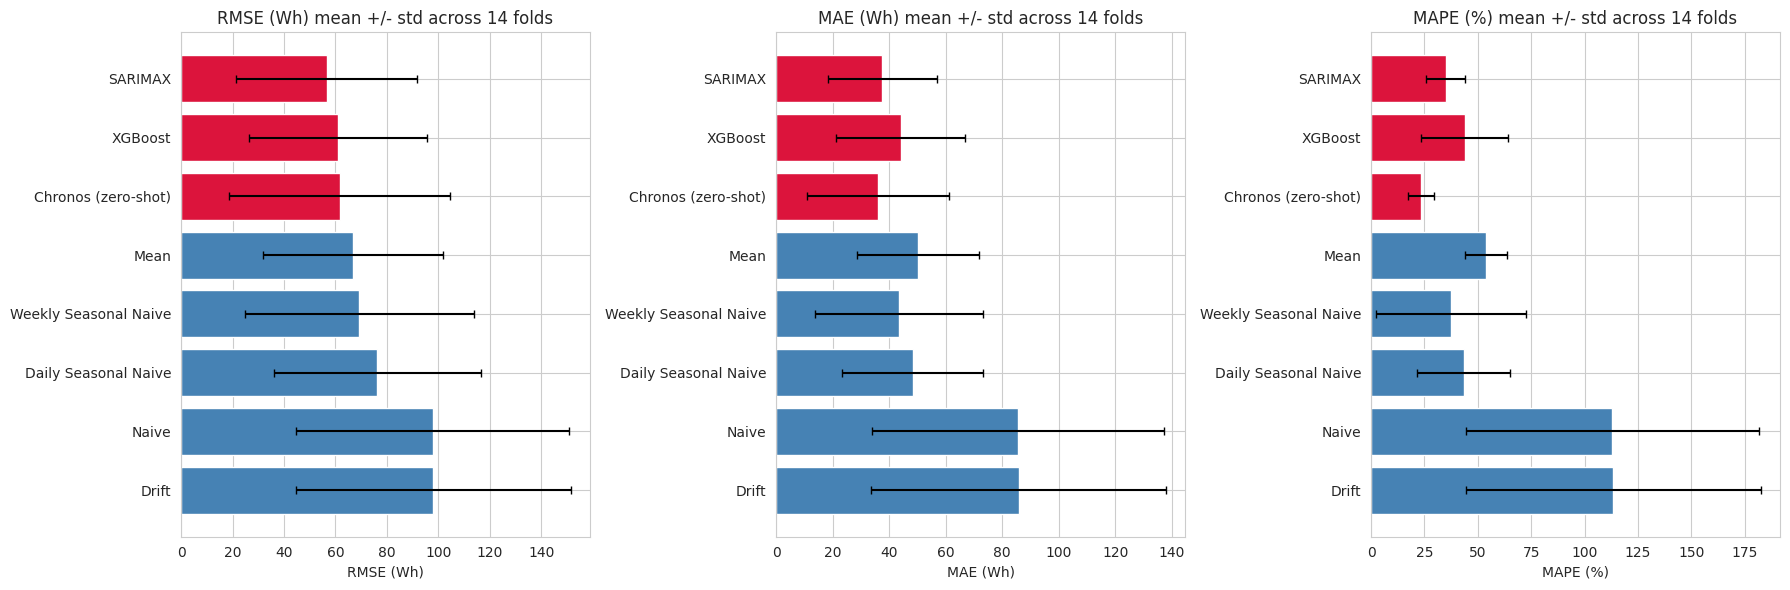

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
metrics_to_plot = [('RMSE_mean', 'RMSE_std', 'RMSE (Wh)'),
                    ('MAE_mean', 'MAE_std', 'MAE (Wh)'),
                    ('MAPE_mean', 'MAPE_std', 'MAPE (%)')]

plot_order = final_comparison.sort_values('RMSE_mean', ascending=True)

for ax, (mean_col, std_col, label) in zip(axes, metrics_to_plot):
    colors = ['crimson' if m in ('SARIMAX', 'XGBoost', 'Chronos (zero-shot)') else 'steelblue'
              for m in plot_order['Model']]
    ax.barh(plot_order['Model'], plot_order[mean_col], xerr=plot_order[std_col],
            color=colors, capsize=3)
    ax.set_xlabel(label)
    ax.set_title(f'{label} mean +/- std across 14 folds')
    ax.invert_yaxis()

plt.tight_layout()
plt.savefig('19_final_model_comparison.png', dpi=150)
plt.show()

(Red bars = models built/fit specifically for this study SARIMAX, XGBoost, Chronos;
blue bars = simple benchmarks.)

### 8.3 Per-fold error distribution (boxplots)

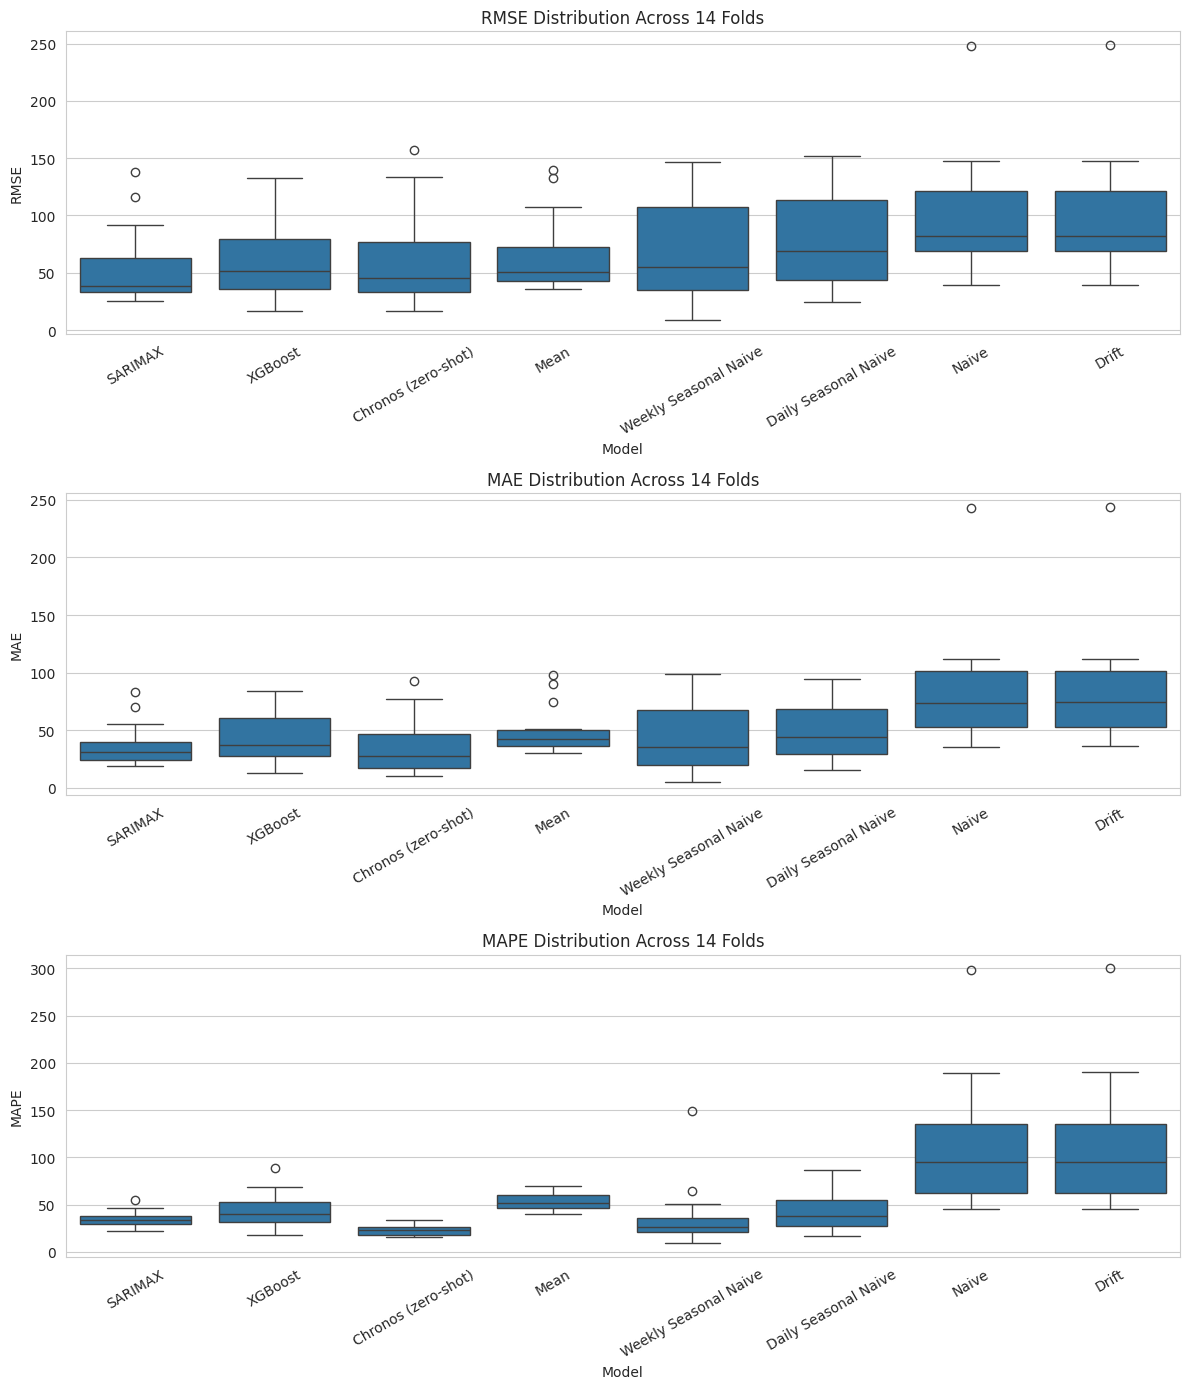

In [ ]:
# Combine per-fold metrics from every model into one long-format DataFrame for boxplots
all_fold_records = []

for model_name, fold_list in benchmark_fold_results.items():
    for fold_i, m in enumerate(fold_list):
        all_fold_records.append({'Model': model_name, 'Fold': fold_i, **m})

for model_name, fold_df in [('SARIMAX', sarimax_fold_df), ('XGBoost', ml_fold_df), ('Chronos (zero-shot)', chronos_fold_df)]:
    for fold_i, row in fold_df.reset_index(drop=True).iterrows():
        all_fold_records.append({'Model': model_name, 'Fold': fold_i,
                                  'RMSE': row['RMSE'], 'MAE': row['MAE'], 'MAPE': row['MAPE']})

all_folds_long = pd.DataFrame(all_fold_records)

# Order models by mean RMSE for consistent, readable plots
model_order = final_comparison.sort_values('RMSE_mean')['Model'].tolist()

fig, axes = plt.subplots(3, 1, figsize=(12, 14))
for ax, metric in zip(axes, ['RMSE', 'MAE', 'MAPE']):
    sns.boxplot(data=all_folds_long, x='Model', y=metric, order=model_order, ax=ax)
    ax.set_title(f'{metric} Distribution Across 14 Folds')
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('20_per_fold_boxplots.png', dpi=150)
plt.show()

### 8.4 Example fold all 8 models overlaid

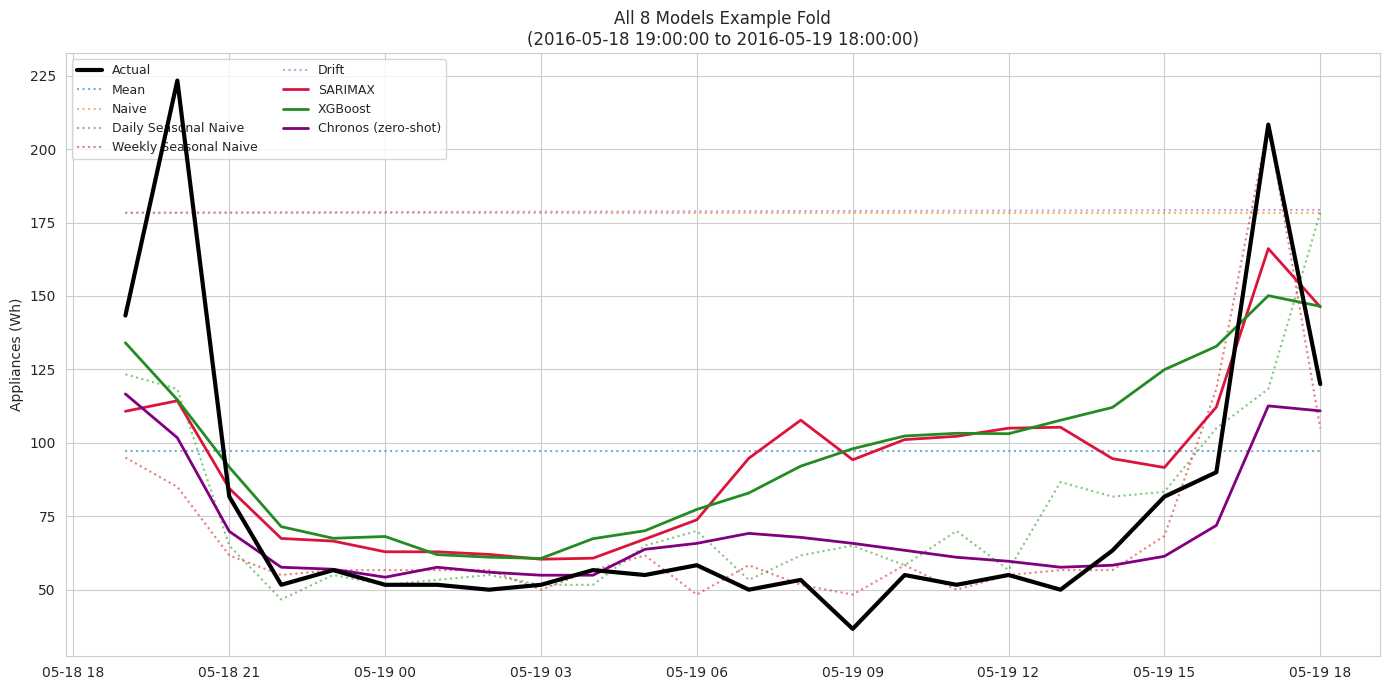

In [ ]:
example_idx = 5
forecast_idx = benchmark_predictions['Mean'][example_idx][0]
y_true = df.loc[forecast_idx, 'Appliances']

fig, ax = plt.subplots(figsize=(14, 7))
ax.plot(forecast_idx, y_true.values, label='Actual', color='black', linewidth=3, zorder=10)

for name in benchmark_models:
    _, y_pred = benchmark_predictions[name][example_idx]
    ax.plot(forecast_idx, y_pred, label=name, linestyle=':', alpha=0.6)

_, sarimax_pred, _ = sarimax_predictions[example_idx]
ax.plot(forecast_idx, sarimax_pred, label='SARIMAX', linewidth=2, color='crimson')

_, ml_pred = ml_predictions[example_idx]
ax.plot(forecast_idx, ml_pred, label='XGBoost', linewidth=2, color='forestgreen')

_, chronos_pred, _, _ = chronos_predictions[example_idx]
ax.plot(forecast_idx, chronos_pred, label='Chronos (zero-shot)', linewidth=2, color='purple')

ax.set_title(f'All 8 Models Example Fold\n({forecast_idx.min()} to {forecast_idx.max()})')
ax.set_ylabel('Appliances (Wh)')
ax.legend(loc='upper left', ncol=2, fontsize=9)
plt.tight_layout()
plt.savefig('21_all_models_example_fold.png', dpi=150)
plt.show()

### 8.5 Improvement over the strongest benchmark

In [ ]:
best_benchmark_rmse = benchmark_summary['RMSE_mean'].min()
best_benchmark_mae = benchmark_summary['MAE_mean'].min()
best_benchmark_mape = benchmark_summary['MAPE_mean'].min()

advanced_models = final_comparison[final_comparison['Model'].isin(['SARIMAX', 'XGBoost', 'Chronos (zero-shot)'])].copy()
advanced_models['RMSE_improvement_%'] = (1 - advanced_models['RMSE_mean'] / best_benchmark_rmse) * 100
advanced_models['MAE_improvement_%'] = (1 - advanced_models['MAE_mean'] / best_benchmark_mae) * 100
advanced_models['MAPE_improvement_%'] = (1 - advanced_models['MAPE_mean'] / best_benchmark_mape) * 100

advanced_models[['Model', 'RMSE_improvement_%', 'MAE_improvement_%', 'MAPE_improvement_%']]

,Model,RMSE_improvement_%,MAE_improvement_%,MAPE_improvement_%
0,SARIMAX,15.263874,13.496177,6.714254
1,XGBoost,8.811243,-1.350480,-17.065316
2,Chronos (zero-shot),7.770171,17.104370,37.740344


**Summary of Part 8**

| Rank | Model | RMSE | MAE | MAPE |
|---|---|---|---|---|
| 1 | **SARIMAX(2,1,6)×(1,0,1,24)** | **56.7** | 37.6 | 34.8% |
| 2 | XGBoost | 61.0 | 44.0 | 43.7% |
| 3 | Chronos (zero-shot) | 61.7 | 36.0 | **23.3%** |
| 4 | Mean (benchmark) | 66.9 | 50.3 | 53.7% |
| 5 | Weekly Seasonal Naive (benchmark) | 69.2 | 43.5 | 37.4% |
| 6 | Daily Seasonal Naive (benchmark) | 76.3 | 48.3 | 43.3% |
| 7 | Naive (benchmark) | 97.8 | 85.6 | 112.9% |
| 8 | Drift (benchmark) | 98.0 | 85.8 | 113.3% |

**Key findings:**
- **SARIMAX wins on RMSE:** the best worst-case control, i.e. it avoids large misses
  better than any other model, despite being a comparatively simple, fully classical
  method with no external features.
- **Chronos wins decisively on MAPE:** (23.3% vs. next-best 34.8%) and is essentially tied
  for best MAE (36.0 vs. SARIMAX's 37.6) this is the standout finding of the whole study:
  a pretrained model with **zero training on this dataset** achieves the best typical-case
  accuracy of any model, including two that were fit directly to this exact series.
- **XGBoost, despite the richest feature set (lags, rolling stats, calendar, weather),
  doesn't clearly beat SARIMAX or Chronos** on any metric a good discussion point: more
  engineered features and a flexible model don't automatically win; here, a well-specified
  classical model and a large pretrained foundation model both outperform it.
- **Per-fold boxplots (8.3)** show *why* SARIMAX wins on RMSE but not MAPE: its box is
  narrow and consistent, but Chronos's per-fold MAPE box is both lower **and** tighter than
  every other model's the most reliable typical-case performer, fold after fold.
- **The overlay plot (8.4)** on a fold with a sharp actual spike (~223 Wh) shows every
  model undershooting the spike none fully captures sudden short bursts of appliance use,
  though SARIMAX and Weekly Seasonal Naive react fastest to the spike, while Chronos and
  XGBoost lag behind it. This is a concrete, visual limitation worth naming in the report.
- Naive and Drift are clearly the weakest models across every metric, confirming this
  series has real, learnable seasonal/temporal structure that even the simplest smarter
  benchmarks (seasonal naive, Mean) already partially capture.



##**Part 9: Analysis Questions**


## Q1. Which benchmark model is strongest naive, mean, daily seasonal naive, weekly seasonal
naive, or drift and what does this tell you about the structure of appliance energy use?

**Mean is the strongest of the five** Among the five benchmarks, Mean achieved the best RMSE (66.91), while Weekly Seasonal Naive achieved the best MAE and MAPE (43.46 / 37.35%), well ahead of Daily Seasonal Naive (76.30 / 48.31 / 43.33%), with Naive and Drift far weakest (RMSE ≈ 98, essentially tied for worst).

This split is informative about the structure of appliance energy use: Mean's strong RMSE comes from avoiding large misses by regressing to a stable average rather than chasing recent fluctuations, while Weekly Seasonal Naive's lower MAE and MAPE show it tracks typical usage more closely by exploiting genuine weekly-cycle structure repeating "the same hour, same day of last week" beats repeating "the same hour yesterday" (Daily Seasonal Naive), implying household routines differ meaningfully by day of week (e.g. weekday vs. weekend patterns) rather than following one fixed daily template. Naive and Drift performing so much worse confirms the series is far from a random walk there's exploitable temporal structure, which is exactly what SARIMAX, XGBoost, and Chronos draw on in later parts.

## Q2. Does the SARIMAX model improve on the strongest seasonal benchmark? Discuss whether
daily seasonality, autocorrelation, and exogenous variables are adequately captured.

**Yes SARIMAX(2,1,6)×(1,0,1,24) improves on Weekly Seasonal Naive across all three
metrics**: RMSE 56.7 vs. 69.2 (18% better), MAE 37.6 vs. 43.5 (14% better), and MAPE 34.8%
vs. 37.4% (a smaller, ~7% relative improvement).

- **Daily seasonality:** adequately captured the seasonal grid search (Part 4.2) showed
  adding the seasonal term (1,0,1,24) dropped AIC substantially versus the best
  non-seasonal ARIMA alone, and the seasonal order was selected by search rather than
  assumed.
- **Autocorrelation:** adequately captured for short lags the residual Ljung-Box test
  was not significant (Ljung-Box Q(1) = 1.06, p ≈ 0.30), meaning no obvious leftover short-lag autocorrelation.
  The residual distribution was skewed and heavy-tailed, though, indicating occasional
  large usage spikes the model doesn't fully explain (visible in the Part 8.4 overlay plot,
  where every model undershoots a ~223 Wh spike).
- **Exogenous variables:** **not captured at all** this SARIMAX is purely univariate on
  `Appliances`; none of the weather/sensor covariates (T_out, RH_out, lights, etc.) were
  incorporated. This is a genuine limitation worth naming explicitly: a SARIMAX model
  using contemporaneous exogenous regressors could potentially improve further, but wasn't
  tested here.

## Q3. Does the XGBoost/feature-based model improve when lag, rolling-window, time-of-day,
and sensor/weather variables are added? Which feature groups appear most useful?

**Partially.** XGBoost (RMSE 61.0, MAE 44.0, MAPE 43.7%) clearly beats Naive, Drift, and
Daily Seasonal Naive, so the engineered features (lags, rolling stats, calendar, current
weather/sensor readings) do add real predictive value over simple persistence-style
baselines. However, XGBoost does **not** beat SARIMAX on any metric, and only edges out
Weekly Seasonal Naive on RMSE (61.0 vs. 69.2) while losing to it on MAE and MAPE.

**Which feature groups are most useful actual result:** the feature importance plot
(Part 6.2) shows a clear and somewhat counter-intuitive ranking. The top of the list is
dominated by **calendar/time-of-day features** `hour`, `hour_cos`, `hour_sin`,
`dow_cos`, `dow_sin`, `dayofweek`, and `month` occupy essentially all of the top 7 slots,
well ahead of every lag feature. `rollmean_168` (the 168-hour/weekly rolling mean) is the
first non-calendar feature to appear, in 8th place.

By contrast, the **raw lag features rank near the bottom** of all 27  `lag_1`, `lag_2`,
`lag_3`, `lag_24`, `lag_48`, and `lag_168` are all in the lower third, with `lag_1`
(intuitively the "safest" feature for 1-step-ahead forecasting) barely more important than
`lag_48`. Weather/sensor readings at `t0` (`T1_t0`, `T_out_t0`, `RH_1_t0`, `Windspeed_t0`,
`Press_mm_hg_t0`, `RH_out_t0`, `lights_t0`) sit in the middle of the ranking more useful
than raw lags, but well behind calendar features and the weekly rolling mean.

**Why this makes sense:** this is a direct consequence of the multi-horizon design from
Part 5 a single model has to forecast anywhere from 1 to 24 hours ahead using the same
feature set, with `horizon` itself as a feature (which lands in the middle of the ranking,
~11th). At horizon 1, `lag_1` would be highly informative, but at horizon 24 it's nearly
irrelevant averaged across all horizons, the model learns that "what time of day and day
of week is being forecast" is a far more stable, horizon-agnostic predictor than "what was
the value N hours before the forecast origin." This also explains why XGBoost doesn't beat
SARIMAX: SARIMAX's ARMA terms exploit short-lag autocorrelation directly and separately at
each horizon via the state-space recursion, while this XGBoost setup dilutes that
short-term signal by forcing one model to generalize across all 24 horizons at once.

## Q4. Does the foundation model outperform the simpler benchmark, SARIMAX, and
feature-based models? Is the improvement, if any, large enough to justify the extra
complexity?

**Mixed but favorable overall.** Chronos (zero-shot): RMSE 61.7, MAE 36.0, MAPE 23.3%.

- **vs. best benchmark (Weekly Seasonal Naive):** Mean has the best benchmark RMSE (66.91) and Weekly Seasonal Naive has the best benchmark MAE/MAPE (43.46 / 37.35%). Chronos beats both on every metric RMSE 61.71 vs. Mean's 66.91 (8% better) and vs. Weekly Seasonal Naive's 69.23 (11% better); MAE 36.02 vs. 43.46 (17% better); MAPE 23.26% vs. 37.35% (38% relative improvement).
- **vs. SARIMAX:** slightly worse RMSE (61.7 vs. 56.7, ~9% higher) but better MAE (36.0 vs.
  37.6) and dramatically better MAPE (23.3% vs. 34.8%, a ~33% relative improvement).
- **vs. XGBoost:** better on every metric.

**Is the improvement worth the complexity?** This is the most interesting trade-off in the
whole study. Chronos required **zero training, no feature engineering, and no
hyperparameter tuning on this data** yet still delivers the best typical-case accuracy
(MAE/MAPE) of all four "real" models. Its main weakness is a higher RMSE standard
deviation (42.97, the largest of any model), meaning it occasionally makes larger misses
that hurt worst-case reliability more than its MAE/MAPE numbers suggest. In practice: if
typical-case accuracy and zero-shot deployability across many households matter most,
Chronos's improvement clearly justifies its complexity (which is mostly *inference-time*
compute, not development effort). If worst-case control matters more (e.g. capacity
planning), SARIMAX's lower RMSE may be preferable despite the extra per-household fitting
effort it requires.

## Q5. Which variables would genuinely be known at the forecast origin? If you use future
indoor temperature, humidity, or weather values from the test set, is this a true forecast
or a conditional forecast?

**Genuinely known at forecast origin (`t0`), for any future timestamp:**
- All **calendar features** hour, day-of-week, weekend flag, month, and their cyclical
  encodings since these are deterministic functions of the clock/calendar and require no
  external information.

**Known only up to `t0`, NOT known for future timestamps in a real deployment:**
- Indoor/outdoor weather and sensor readings (T_out, RH_out, Windspeed, T1, RH_1, lights,
  etc.). We only know their **current** value at the moment the forecast is made we
  cannot know what the actual temperature or humidity will be 15 hours from now without
  either (a) a genuine external weather forecast, or (b) cheating by looking at the test
  set's realized future values.

**This is precisely why Part 5's feature design only used *current* (`t0`) weather/sensor
readings**, never future ones, even though the raw dataset technically contains the future
values (since it's historical data). If a model instead used the test set's actual future
`T_out`/`RH_out` values as input features, it would **not be a true forecast** it would
be a **conditional forecast**: "what indoor usage would be, *given* that these exact future
weather conditions occur." That's a fundamentally different (and easier, information-
leaking) task than what's asked here a legitimate deployed system would need real
weather *forecasts* (with their own uncertainty) as inputs to attempt this honestly, and
even then the result is conditional on the accuracy of that external forecast, not a pure
autonomous prediction from the energy series alone.

## Q6. Based on accuracy, interpretability, uncertainty, computational cost, and ease of
deployment, which model would you recommend for practical smart-home energy forecasting,
and why?

| Criterion | SARIMAX | XGBoost | Chronos (zero-shot) |
|---|---|---|---|
| **Accuracy** | Best RMSE (56.7) | Middling on all metrics | Best MAE/MAPE, competitive RMSE |
| **Interpretability** | High explicit order, coefficients, residual diagnostics | Medium feature importances, but tree ensemble is a black box internally | Low large pretrained transformer, no interpretable structure |
| **Uncertainty** | Principled confidence intervals from the state-space model | None natively (would need quantile regression / conformal prediction added) | Principled, sample-based quantile intervals built in |
| **Computational cost** | Cheap to fit per household (seconds); needs a one-time order search | Fast to train per fold, but needs a full feature pipeline maintained | Zero training cost; heavier per-call inference (transformer forward pass), lighter on GPU |
| **Ease of deployment** | Needs enough per-household history before a good order can be fit cold-start issue for new households | Same cold-start issue, plus a feature pipeline to build and maintain per household | **No training or tuning needed per household at all** works immediately on a brand-new household with only a short history |

**Recommendation: Chronos (zero-shot)**, for a smart-home product deployed across many
households its combination of best typical-case accuracy, built-in uncertainty
quantiles, and **zero cold-start requirement** (no per-household training/tuning) makes it
the most practically deployable option at scale, despite being the least interpretable.

**Caveat:** if the application specifically needs worst-case reliability (e.g. grid
capacity planning, where occasional large misses are costly) or requires an interpretable,
auditable model (e.g. for regulatory or diagnostic purposes), **SARIMAX** remains the
stronger choice given its best RMSE, transparent structure, and principled intervals
at the cost of needing enough history per household to fit it well.

XGBoost is hardest to recommend here: it requires the most engineering effort (feature
pipeline, per-fold retraining) of the three "real" models, yet doesn't clearly outperform
either SARIMAX or Chronos on any metric in this study.

###**GitHub:** https://github.com/mh25afc/appliance-energy-forecasting